# Final Project Synthesis — Black Hole Observational Memory Project

This notebook consolidates the complete project from Phase 1 to Phase 8-A.

It produces a final audit containing:

- Phase 1–8 timeline
- all major available final tables
- all major available figures
- validation summaries
- final scientific claim boundaries
- publication/thesis-ready export files

The notebook is designed to run inside:

```text
/home/marwa/files/phase1_blackhole_generator
```

It does not retrain models. It only audits, loads, summarizes, visualizes, and exports the project results.

In [1]:
# ================================================================
# 1. Imports and global configuration
# ================================================================

import os
import json
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image as IPImage
except Exception:
    display = print
    Markdown = lambda x: x

PROJECT_ROOT = Path('/home/marwa/files/phase1_blackhole_generator')
DATA_ROOT = PROJECT_ROOT / 'data'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'

FINAL_DIR = OUTPUT_ROOT / 'final_project_synthesis'
FINAL_TABLE_DIR = FINAL_DIR / 'tables'
FINAL_FIG_DIR = FINAL_DIR / 'figures'
FINAL_REPORT_DIR = FINAL_DIR / 'reports'
FINAL_ASSET_DIR = FINAL_DIR / 'major_assets'

for d in [FINAL_DIR, FINAL_TABLE_DIR, FINAL_FIG_DIR, FINAL_REPORT_DIR, FINAL_ASSET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PHASE_DIRS = {
    'phase7A': OUTPUT_ROOT / 'phase7A_real_observation_consistency',
    'phase7B': OUTPUT_ROOT / 'phase7B_synthetic_to_real_calibration',
    'phase7C': OUTPUT_ROOT / 'phase7C_calibration_robustness',
    'phase7D': OUTPUT_ROOT / 'phase7D_calibrated_memory_mapping',
    'phase7D1': OUTPUT_ROOT / 'phase7D1_metadata_recovery_event_family_reconstruction',
    'phase8A': OUTPUT_ROOT / 'phase8A_expanded_real_grmhd_validation',
    'final_audit_old': OUTPUT_ROOT / 'final_audit_synthesis',
}

BRIDGE_DATASET = 'phase7A2_grmhd_harvest'
REFERENCE_DATASETS = [
    'phase1_original',
    'phase5_8_morphology',
    'phase5_coupled',
    'phase6_memory',
    'phase7A2_grmhd_harvest',
]

print('Project root:', PROJECT_ROOT)
print('Output root:', OUTPUT_ROOT)
print('Final synthesis directory:', FINAL_DIR)
print('Created:', datetime.now().isoformat())

Project root: /home/marwa/files/phase1_blackhole_generator
Output root: /home/marwa/files/phase1_blackhole_generator/outputs
Final synthesis directory: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis
Created: 2026-06-19T21:00:44.880174


/home/marwa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ================================================================
# 2. Utility functions
# ================================================================

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    except Exception as e:
        print('Could not read CSV:', path, e)
        return None

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print('Could not read JSON:', path, e)
        return None

def save_dataframe(df, name, index=False):
    path = FINAL_TABLE_DIR / f'{name}.csv'
    df.to_csv(path, index=index)
    return path

def save_plot(name):
    path = FINAL_FIG_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

def copy_asset(src, dst_dir=FINAL_ASSET_DIR):
    src = Path(src)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    if src.exists() and src.is_file():
        dst = dst_dir / src.name
        shutil.copy2(src, dst)
        return dst
    return None

def df_to_text(df, max_rows=25):
    if df is None or len(df) == 0:
        return 'No data available.'
    return df.head(max_rows).to_string(index=False)

def file_exists(path):
    return Path(path).exists()

def load_table(path, label):
    df = read_csv_if_exists(path)
    loaded_tables[label] = df
    return df

loaded_tables = {}
print('Utilities ready.')

Utilities ready.


## Part I — Phase 1–8 Timeline

This section defines the final conceptual timeline of the project. It is manually curated because not all early exploratory phases necessarily produced standardized CSV outputs.

In [3]:
# ================================================================
# 3. Phase 1–8 timeline
# ================================================================

timeline_rows = [
    {
        'phase': 'Phase 1',
        'name': 'Synthetic Black Hole Universe',
        'objective': 'Generate controlled synthetic black-hole observations with known physical parameters.',
        'main_output': 'Baseline synthetic image datasets.',
        'scientific_role': 'Creates the controlled universe where ground truth is known.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 2',
        'name': 'Observation Reconstruction',
        'objective': 'Train reconstruction models to recover clean morphology from noisy observations.',
        'main_output': 'U-Net reconstruction outputs and memory-preserving model lineage.',
        'scientific_role': 'Preserves image structure needed for later memory analysis.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 4',
        'name': 'Physical Parameter Recovery',
        'objective': 'Estimate hidden physical parameters from images.',
        'main_output': 'Exploratory parameter-prediction experiments.',
        'scientific_role': 'Revealed limits of direct parameter inference and motivated memory framing.',
        'status': 'exploratory completed',
    },
    {
        'phase': 'Phase 5',
        'name': 'Physics-to-Image Coupling',
        'objective': 'Improve coupling between physical parameters and visible morphology.',
        'main_output': 'Phase 5 coupled and Phase 5.8 morphology datasets.',
        'scientific_role': 'Makes synthetic images more morphologically informative.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 6',
        'name': 'Static Memory Persistence',
        'objective': 'Test whether a final static image retains information about past events.',
        'main_output': 'Memory persistence model, memory curves, event-type and age metrics.',
        'scientific_role': 'Introduces observational memory and memory persistence.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 6-T',
        'name': 'Late Temporal Observation',
        'objective': 'Test whether late-stage temporal clips improve event recovery.',
        'main_output': 'Temporal memory model and late observation metrics.',
        'scientific_role': 'Shows late temporal information has limited recovery benefit.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 6-U',
        'name': 'Event-Centered Observation',
        'objective': 'Test event-centered clips where the event is directly observed.',
        'main_output': 'Event-centered temporal model and validation metrics.',
        'scientific_role': 'Shows event identity is far more recoverable than event timing.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 7-A',
        'name': 'Real Observation Consistency Study',
        'objective': 'Compare synthetic domains against real EHT observations in morphology and latent space.',
        'main_output': 'Domain-distance summaries and nearest-neighbor tables.',
        'scientific_role': 'Identifies the GRMHD-inspired bridge domain as closest to real observations.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 7-A.2',
        'name': 'GRMHD Image Harvesting',
        'objective': 'Create a GRMHD-inspired morphology bridge between synthetic and real observations.',
        'main_output': 'Phase7A2 GRMHD-inspired proxy image library.',
        'scientific_role': 'Supplies the bridge domain later validated across phases.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 7-B',
        'name': 'Synthetic-to-Real Latent Calibration',
        'objective': 'Calibrate synthetic latent features toward real EHT latent space.',
        'main_output': 'Baseline, mean-shift, and ridge calibration distance summaries.',
        'scientific_role': 'Shows structured calibration substantially improves synthetic-to-real alignment.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 7-C',
        'name': 'Calibration Robustness',
        'objective': 'Test calibration robustness using leave-one-real-out and bootstrap validation.',
        'main_output': 'Robustness criteria, rankings, bootstrap and LOO summaries.',
        'scientific_role': 'Prevents overclaiming by showing conditional but stable calibration robustness.',
        'status': 'conditional pass',
    },
    {
        'phase': 'Phase 7-D',
        'name': 'Calibrated Synthetic Analogue Memory Mapping',
        'objective': 'Map real observations to calibrated synthetic analogue families.',
        'main_output': 'Analogue confidence scores and dataset/family distributions.',
        'scientific_role': 'Converts alignment into interpretable analogue mapping.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 7-D.1',
        'name': 'Metadata Recovery and Event-Family Reconstruction',
        'objective': 'Recover event-family and physical-state metadata for analogue outputs.',
        'main_output': 'Reconstructed family and physical-proxy summaries.',
        'scientific_role': 'Adds interpretable physical proxy descriptors to analogue mapping.',
        'status': 'completed',
    },
    {
        'phase': 'Phase 8-A',
        'name': 'Expanded Real and GRMHD Validation',
        'objective': 'Test whether the bridge-domain conclusion survives expanded external validation.',
        'main_output': 'Expanded validation status, bridge stability tests, external source audit.',
        'scientific_role': 'Confirms the bridge domain remains stable after adding independent EHT-imaging outputs.',
        'status': 'PASS',
    },
]

timeline_df = pd.DataFrame(timeline_rows)
display(timeline_df)
timeline_path = save_dataframe(timeline_df, 'final_phase_1_to_8_timeline')
print('Saved:', timeline_path)

,phase,name,objective,main_output,scientific_role,status
0,Phase 1,Synthetic Black Hole Universe,Generate controlled synthetic black-hole obser...,Baseline synthetic image datasets.,Creates the controlled universe where ground t...,completed
1,Phase 2,Observation Reconstruction,Train reconstruction models to recover clean m...,U-Net reconstruction outputs and memory-preser...,Preserves image structure needed for later mem...,completed
2,Phase 4,Physical Parameter Recovery,Estimate hidden physical parameters from images.,Exploratory parameter-prediction experiments.,Revealed limits of direct parameter inference ...,exploratory completed
3,Phase 5,Physics-to-Image Coupling,Improve coupling between physical parameters a...,Phase 5 coupled and Phase 5.8 morphology datas...,Makes synthetic images more morphologically in...,completed
4,Phase 6,Static Memory Persistence,Test whether a final static image retains info...,"Memory persistence model, memory curves, event...",Introduces observational memory and memory per...,completed
5,Phase 6-T,Late Temporal Observation,Test whether late-stage temporal clips improve...,Temporal memory model and late observation met...,Shows late temporal information has limited re...,completed
6,Phase 6-U,Event-Centered Observation,Test event-centered clips where the event is d...,Event-centered temporal model and validation m...,Shows event identity is far more recoverable t...,completed
7,Phase 7-A,Real Observation Consistency Study,Compare synthetic domains against real EHT obs...,Domain-distance summaries and nearest-neighbor...,Identifies the GRMHD-inspired bridge domain as...,completed
8,Phase 7-A.2,GRMHD Image Harvesting,Create a GRMHD-inspired morphology bridge betw...,Phase7A2 GRMHD-inspired proxy image library.,Supplies the bridge domain later validated acr...,completed
9,Phase 7-B,Synthetic-to-Real Latent Calibration,Calibrate synthetic latent features toward rea...,"Baseline, mean-shift, and ridge calibration di...",Shows structured calibration substantially imp...,completed


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_phase_1_to_8_timeline.csv


## Part II — Load All Major Final Tables

This section loads the most important CSV outputs from Phase 7-A through Phase 8-A and any earlier final audit tables if available.

In [4]:
# ================================================================
# 4. Load major tables from all phases
# ================================================================

TABLE_SPECS = {
    # Phase 7-A
    'phase7A_domain_distance_summary': PHASE_DIRS['phase7A'] / 'tables' / 'phase7A_domain_distance_summary.csv',
    'phase7A_morphology_features': PHASE_DIRS['phase7A'] / 'tables' / 'phase7A_morphology_features.csv',
    'phase7A_unet_latent_features': PHASE_DIRS['phase7A'] / 'tables' / 'phase7A_unet_latent_features.csv',
    'phase7A_nearest_synthetic_neighbors': PHASE_DIRS['phase7A'] / 'tables' / 'phase7A_nearest_synthetic_neighbors.csv',
    'phase7A_real_image_index': PHASE_DIRS['phase7A'] / 'tables' / 'phase7A_real_image_index.csv',
    'phase7A_synthetic_image_index': PHASE_DIRS['phase7A'] / 'tables' / 'phase7A_synthetic_image_index.csv',

    # Phase 7-B
    'phase7B_calibration_distance_comparison': PHASE_DIRS['phase7B'] / 'tables' / 'phase7B_calibration_distance_comparison.csv',
    'phase7B_calibration_improvement_summary': PHASE_DIRS['phase7B'] / 'tables' / 'phase7B_calibration_improvement_summary.csv',
    'phase7B_ridge_calibrated_distance_summary': PHASE_DIRS['phase7B'] / 'tables' / 'phase7B_ridge_calibrated_distance_summary.csv',

    # Phase 7-C
    'phase7C_robustness_criteria': PHASE_DIRS['phase7C'] / 'tables' / 'phase7C_robustness_criteria.csv',
    'phase7C_robustness_rankings': PHASE_DIRS['phase7C'] / 'tables' / 'phase7C_robustness_rankings.csv',
    'phase7C_leave_one_real_out_summary': PHASE_DIRS['phase7C'] / 'tables' / 'phase7C_leave_one_real_out_summary.csv',
    'phase7C_bootstrap_summary': PHASE_DIRS['phase7C'] / 'tables' / 'phase7C_bootstrap_summary.csv',

    # Phase 7-D
    'phase7D_thesis_style_analogue_results': PHASE_DIRS['phase7D'] / 'tables' / 'phase7D_thesis_style_analogue_results.csv',
    'phase7D_analogue_confidence_scores': PHASE_DIRS['phase7D'] / 'tables' / 'phase7D_analogue_confidence_scores.csv',
    'phase7D_dataset_origin_distribution': PHASE_DIRS['phase7D'] / 'tables' / 'phase7D_dataset_origin_distribution_by_real_observation.csv',

    # Phase 7-D.1
    'phase7D1_thesis_style_reconstructed_results': PHASE_DIRS['phase7D1'] / 'tables' / 'phase7D1_thesis_style_reconstructed_results.csv',
    'phase7D1_reconstructed_physical_parameter_summary': PHASE_DIRS['phase7D1'] / 'tables' / 'phase7D1_reconstructed_physical_parameter_summary.csv',
    'phase7D1_metadata_coverage_summary': PHASE_DIRS['phase7D1'] / 'tables' / 'phase7D1_metadata_coverage_summary.csv',

    # Phase 8-A
    'phase8A_validation_status': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_validation_status.csv',
    'phase8A_validation_criteria': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_validation_criteria.csv',
    'phase8A_bridge_stability_tests': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_bridge_stability_tests.csv',
    'phase8A_bridge_stability_summary': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_bridge_stability_summary.csv',
    'phase8A_external_source_audit': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_external_source_audit.csv',
    'phase8A_external_source_nearest_domain_distribution': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_external_source_nearest_domain_distribution.csv',
    'phase8A_morphology_domain_distance_summary': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_morphology_domain_distance_summary.csv',
    'phase8A_phase7D1_physical_proxy_synthesis': PHASE_DIRS['phase8A'] / 'tables' / 'phase8A_phase7D1_physical_proxy_synthesis.csv',

    # Earlier final audit, if it exists
    'early_final_metrics_summary': PHASE_DIRS['final_audit_old'] / 'tables' / 'metrics_summary.csv',
    'early_final_phase_comparison': PHASE_DIRS['final_audit_old'] / 'tables' / 'phase_comparison.csv',
    'early_final_memory_curves': PHASE_DIRS['final_audit_old'] / 'tables' / 'final_memory_curves_by_age.csv',
}

inventory_rows = []
for label, path in TABLE_SPECS.items():
    df = load_table(path, label)
    inventory_rows.append({
        'label': label,
        'path': str(path),
        'exists': Path(path).exists(),
        'loaded': df is not None,
        'rows': len(df) if df is not None else 0,
        'columns': len(df.columns) if df is not None else 0,
    })

table_inventory_df = pd.DataFrame(inventory_rows)
display(table_inventory_df)
table_inventory_path = save_dataframe(table_inventory_df, 'final_major_table_inventory')
print('Saved:', table_inventory_path)

,label,path,exists,loaded,rows,columns
0,phase7A_domain_distance_summary,/home/marwa/files/phase1_blackhole_generator/o...,True,True,10,7
1,phase7A_morphology_features,/home/marwa/files/phase1_blackhole_generator/o...,True,True,2508,26
2,phase7A_unet_latent_features,/home/marwa/files/phase1_blackhole_generator/o...,True,True,2508,516
3,phase7A_nearest_synthetic_neighbors,/home/marwa/files/phase1_blackhole_generator/o...,False,False,0,0
4,phase7A_real_image_index,/home/marwa/files/phase1_blackhole_generator/o...,True,True,8,6
5,phase7A_synthetic_image_index,/home/marwa/files/phase1_blackhole_generator/o...,True,True,2500,59
6,phase7B_calibration_distance_comparison,/home/marwa/files/phase1_blackhole_generator/o...,True,True,15,8
7,phase7B_calibration_improvement_summary,/home/marwa/files/phase1_blackhole_generator/o...,True,True,10,6
8,phase7B_ridge_calibrated_distance_summary,/home/marwa/files/phase1_blackhole_generator/o...,True,True,5,7
9,phase7C_robustness_criteria,/home/marwa/files/phase1_blackhole_generator/o...,True,True,4,3


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_major_table_inventory.csv


In [5]:
# ================================================================
# 5. Display compact previews of critical final tables
# ================================================================

critical_labels = [
    'phase7A_domain_distance_summary',
    'phase7B_calibration_distance_comparison',
    'phase7C_robustness_criteria',
    'phase7C_robustness_rankings',
    'phase7D1_thesis_style_reconstructed_results',
    'phase8A_validation_status',
    'phase8A_bridge_stability_tests',
    'phase8A_external_source_audit',
]

for label in critical_labels:
    print('\n' + '=' * 90)
    print(label)
    print('=' * 90)
    df = loaded_tables.get(label)
    if df is None or len(df) == 0:
        print('Not available or empty.')
    else:
        display(df.head(20))


phase7A_domain_distance_summary


,space,synthetic_dataset,mean_min_distance_real_to_synthetic,median_min_distance_real_to_synthetic,mean_pairwise_distance,n_real,n_synthetic
0,morphology,phase1_original,4.710267,5.160894,8.795517,8,500
1,morphology,phase5_8_morphology,5.299546,5.040775,8.028444,8,500
2,morphology,phase5_coupled,5.366375,4.795664,8.339581,8,500
3,morphology,phase6_memory,7.070308,6.489679,8.383772,8,500
4,morphology,phase7A2_grmhd_harvest,2.472881,3.269550,8.153316,8,500
5,unet_latent,phase1_original,9.570396,9.356956,33.040386,8,500
6,unet_latent,phase5_8_morphology,12.768690,11.367983,25.493828,8,500
7,unet_latent,phase5_coupled,13.922192,10.436476,35.714207,8,500
8,unet_latent,phase6_memory,21.732309,14.405910,35.690617,8,500
9,unet_latent,phase7A2_grmhd_harvest,6.081075,9.280736,27.322515,8,500



phase7B_calibration_distance_comparison


,space,synthetic_dataset,mean_min_distance_real_to_synthetic,median_min_distance_real_to_synthetic,mean_pairwise_distance,n_real,n_synthetic,calibration
0,unet_latent_baseline,phase7A2_grmhd_harvest,6.081075,9.280736,27.322515,8,500,baseline
1,unet_latent_baseline,phase1_original,9.570396,9.356956,33.040386,8,500,baseline
2,unet_latent_baseline,phase5_8_morphology,12.768690,11.367983,25.493828,8,500,baseline
3,unet_latent_baseline,phase5_coupled,13.922192,10.436476,35.714207,8,500,baseline
4,unet_latent_baseline,phase6_memory,21.732309,14.405910,35.690617,8,500,baseline
5,unet_latent_mean_shift_calibrated,phase5_coupled,10.684422,10.448938,30.838076,8,500,mean_shift
6,unet_latent_mean_shift_calibrated,phase5_8_morphology,10.839859,10.981407,25.136312,8,500,mean_shift
7,unet_latent_mean_shift_calibrated,phase1_original,11.229382,10.858184,31.813793,8,500,mean_shift
8,unet_latent_mean_shift_calibrated,phase7A2_grmhd_harvest,12.169247,11.666891,21.877321,8,500,mean_shift
9,unet_latent_mean_shift_calibrated,phase6_memory,18.049973,15.331461,31.381710,8,500,mean_shift



phase7C_robustness_criteria


...

,phase8A_status,criteria_passed,criteria_total,n_external_images,n_external_grmhd_images,bridge_stability_score
0,PASS,5,5,2430,10,1.0



phase8A_bridge_stability_tests


,test,best_dataset,metric,value,bridge_dataset,bridge_is_best
0,expanded_morphology_best_domain,phase7A2_grmhd_harvest,mean_min_distance_external_to_synthetic,2.672039,phase7A2_grmhd_harvest,True
1,phase7A_original_morphology_best_domain,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,2.472881,phase7A2_grmhd_harvest,True
2,phase7A_original_unet_latent_best_domain,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,6.081075,phase7A2_grmhd_harvest,True
3,phase7C_baseline_rank1,phase7A2_grmhd_harvest,ranking_distance,6.081075,phase7A2_grmhd_harvest,True
4,phase7C_bootstrap_rank1,phase7A2_grmhd_harvest,ranking_distance,6.531777,phase7A2_grmhd_harvest,True
5,phase7C_leave_one_out_rank1,phase7A2_grmhd_harvest,ranking_distance,4.468646,phase7A2_grmhd_harvest,True



phase8A_external_source_audit


,source_group,dataset_name,path,exists,description,n_image_files,n_data_products,preview_images,preview_data_products
0,real_eht,real_eht_m87,/home/marwa/files/phase1_blackhole_generator/d...,True,M87* EHT or EHT-like event-horizon-scale images,5,0,m87_2017.png; m87_2018.png; m87_2019_first_ima...,NaN
1,real_eht,real_eht_sgra,/home/marwa/files/phase1_blackhole_generator/d...,True,Sagittarius A* EHT or EHT-like event-horizon-s...,3,0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,NaN
2,real_external,real_external_misc,/home/marwa/files/phase1_blackhole_generator/d...,True,Other real or external black-hole observation ...,0,0,NaN,NaN
3,grmhd_proxy,phase7A2_grmhd_harvest_clean,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy clean images,1206,0,grmhd_ext_00001.png; grmhd_ext_00002.png; grmh...,NaN
4,grmhd_proxy,phase7A2_grmhd_harvest_noisy,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy noisy images,1206,0,grmhd_ext_00001_noisy.png; grmhd_ext_00002_noi...,NaN
5,external_grmhd,external_grmhd_images,/home/marwa/files/phase1_blackhole_generator/d...,True,User-supplied rendered GRMHD images,10,0,ehtim_rowan_m87_closure_blur_clean_beam.png; e...,NaN
6,raw_grmhd,raw_grmhd_products,/home/marwa/files/phase1_blackhole_generator/d...,True,Raw GRMHD data products such as HDF5/FITS snap...,0,0,NaN,NaN


## Part III — Validation Summaries

This section builds a final validation scorecard from the major completed phases.

In [6]:
# ================================================================
# 6. Build final validation scorecard
# ================================================================

score_rows = []

# Phase 7-A best domains
phase7A_domain_df = loaded_tables.get('phase7A_domain_distance_summary')
if phase7A_domain_df is not None and len(phase7A_domain_df):
    col = 'mean_min_distance_real_to_synthetic'
    if col in phase7A_domain_df.columns:
        for space, sub in phase7A_domain_df.groupby('space') if 'space' in phase7A_domain_df.columns else [('unknown', phase7A_domain_df)]:
            best = sub.sort_values(col).iloc[0]
            score_rows.append({
                'validation_layer': f'Phase 7-A {space}',
                'test_type': 'domain distance',
                'best_domain': best.get('synthetic_dataset', ''),
                'metric_name': col,
                'metric_value': float(best[col]),
                'bridge_is_best': bool(best.get('synthetic_dataset', '') == BRIDGE_DATASET),
                'status': 'pass' if best.get('synthetic_dataset', '') == BRIDGE_DATASET else 'review',
            })

# Phase 7-C rankings
phase7C_rankings_df = loaded_tables.get('phase7C_robustness_rankings')
if phase7C_rankings_df is not None and len(phase7C_rankings_df):
    for validation, sub in phase7C_rankings_df.groupby('validation'):
        best = sub.sort_values('rank').iloc[0]
        score_rows.append({
            'validation_layer': f'Phase 7-C {validation}',
            'test_type': 'robustness ranking',
            'best_domain': best.get('synthetic_dataset', ''),
            'metric_name': 'ranking_distance',
            'metric_value': float(best.get('ranking_distance', np.nan)),
            'bridge_is_best': bool(best.get('synthetic_dataset', '') == BRIDGE_DATASET),
            'status': 'pass' if best.get('synthetic_dataset', '') == BRIDGE_DATASET else 'review',
        })

# Phase 8-A expanded morphology
phase8A_morph_df = loaded_tables.get('phase8A_morphology_domain_distance_summary')
if phase8A_morph_df is not None and len(phase8A_morph_df):
    col = 'mean_min_distance_external_to_synthetic'
    best = phase8A_morph_df.sort_values(col).iloc[0]
    score_rows.append({
        'validation_layer': 'Phase 8-A expanded morphology',
        'test_type': 'expanded domain distance',
        'best_domain': best.get('synthetic_dataset', ''),
        'metric_name': col,
        'metric_value': float(best.get(col, np.nan)),
        'bridge_is_best': bool(best.get('synthetic_dataset', '') == BRIDGE_DATASET),
        'status': 'pass' if best.get('synthetic_dataset', '') == BRIDGE_DATASET else 'review',
    })

validation_scorecard_df = pd.DataFrame(score_rows)
if len(validation_scorecard_df):
    bridge_score = float(validation_scorecard_df['bridge_is_best'].mean())
else:
    bridge_score = np.nan

validation_summary_df = pd.DataFrame([{
    'n_validation_layers': len(validation_scorecard_df),
    'n_bridge_best': int(validation_scorecard_df['bridge_is_best'].sum()) if len(validation_scorecard_df) else 0,
    'bridge_consistency_score': bridge_score,
    'final_interpretation': 'Bridge domain is consistently selected across available validation layers.' if bridge_score == 1.0 else 'Bridge domain is not consistently selected across all available validation layers.',
}])

display(validation_scorecard_df)
display(validation_summary_df)

scorecard_path = save_dataframe(validation_scorecard_df, 'final_validation_scorecard')
validation_summary_path = save_dataframe(validation_summary_df, 'final_validation_summary')
print('Saved:', scorecard_path)
print('Saved:', validation_summary_path)

,validation_layer,test_type,best_domain,metric_name,metric_value,bridge_is_best,status
0,Phase 7-A morphology,domain distance,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,2.472881,True,pass
1,Phase 7-A unet_latent,domain distance,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,6.081075,True,pass
2,Phase 7-C baseline,robustness ranking,phase7A2_grmhd_harvest,ranking_distance,6.081075,True,pass
3,Phase 7-C bootstrap,robustness ranking,phase7A2_grmhd_harvest,ranking_distance,6.531777,True,pass
4,Phase 7-C leave_one_out,robustness ranking,phase7A2_grmhd_harvest,ranking_distance,4.468646,True,pass
5,Phase 8-A expanded morphology,expanded domain distance,phase7A2_grmhd_harvest,mean_min_distance_external_to_synthetic,2.672039,True,pass


,n_validation_layers,n_bridge_best,bridge_consistency_score,final_interpretation
0,6,6,1.0,Bridge domain is consistently selected across ...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_validation_scorecard.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_validation_summary.csv


In [7]:
# ================================================================
# 7. Phase 8-A final status extraction
# ================================================================

phase8A_status_df = loaded_tables.get('phase8A_validation_status')
phase8A_criteria_df = loaded_tables.get('phase8A_validation_criteria')
phase8A_external_df = loaded_tables.get('phase8A_external_source_audit')

if phase8A_status_df is not None and len(phase8A_status_df):
    display(phase8A_status_df)

if phase8A_criteria_df is not None and len(phase8A_criteria_df):
    display(phase8A_criteria_df)

if phase8A_external_df is not None and len(phase8A_external_df):
    display(phase8A_external_df)

,phase8A_status,criteria_passed,criteria_total,n_external_images,n_external_grmhd_images,bridge_stability_score
0,PASS,5,5,2430,10,1.0


,criterion,passed,observed_value,interpretation
0,At least 8 external/EHT-like images are indexed,True,2430,Minimum threshold matches or exceeds the origi...
1,External rendered GRMHD images beyond Phase 7A...,True,10,This is preferred for genuine expanded validat...
2,Bridge domain ranks first in expanded morpholo...,True,phase7A2_grmhd_harvest,Tests whether the Phase 7 bridge conclusion su...
3,Bridge stability score is at least 0.75 across...,True,1.0,Fraction of available validation tests where t...
4,Physical-proxy analogue summaries are availabl...,True,8,Confirms Phase 8-A can carry forward physical-...


,source_group,dataset_name,path,exists,description,n_image_files,n_data_products,preview_images,preview_data_products
0,real_eht,real_eht_m87,/home/marwa/files/phase1_blackhole_generator/d...,True,M87* EHT or EHT-like event-horizon-scale images,5,0,m87_2017.png; m87_2018.png; m87_2019_first_ima...,NaN
1,real_eht,real_eht_sgra,/home/marwa/files/phase1_blackhole_generator/d...,True,Sagittarius A* EHT or EHT-like event-horizon-s...,3,0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,NaN
2,real_external,real_external_misc,/home/marwa/files/phase1_blackhole_generator/d...,True,Other real or external black-hole observation ...,0,0,NaN,NaN
3,grmhd_proxy,phase7A2_grmhd_harvest_clean,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy clean images,1206,0,grmhd_ext_00001.png; grmhd_ext_00002.png; grmh...,NaN
4,grmhd_proxy,phase7A2_grmhd_harvest_noisy,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy noisy images,1206,0,grmhd_ext_00001_noisy.png; grmhd_ext_00002_noi...,NaN
5,external_grmhd,external_grmhd_images,/home/marwa/files/phase1_blackhole_generator/d...,True,User-supplied rendered GRMHD images,10,0,ehtim_rowan_m87_closure_blur_clean_beam.png; e...,NaN
6,raw_grmhd,raw_grmhd_products,/home/marwa/files/phase1_blackhole_generator/d...,True,Raw GRMHD data products such as HDF5/FITS snap...,0,0,NaN,NaN


## Part IV — All Major Figures and Assets

This section indexes, copies, and displays the most important figure files generated by the project.

In [8]:
# ================================================================
# 8. Collect major figure files
# ================================================================

FIGURE_DIRS = {
    'phase7A_figures': PHASE_DIRS['phase7A'] / 'figures',
    'phase7B_figures': PHASE_DIRS['phase7B'] / 'figures',
    'phase7C_figures': PHASE_DIRS['phase7C'] / 'figures',
    'phase7D_figures': PHASE_DIRS['phase7D'] / 'figures',
    'phase7D1_figures': PHASE_DIRS['phase7D1'] / 'figures',
    'phase8A_figures': PHASE_DIRS['phase8A'] / 'figures',
    'phase8A_assets': PHASE_DIRS['phase8A'] / 'copied_key_assets',
    'early_final_figures': PHASE_DIRS['final_audit_old'] / 'figures',
}

figure_rows = []
for group, folder in FIGURE_DIRS.items():
    folder = Path(folder)
    if folder.exists():
        for p in sorted(folder.rglob('*')):
            if p.is_file() and p.suffix.lower() in ['.png', '.jpg', '.jpeg', '.webp']:
                copied = copy_asset(p)
                figure_rows.append({
                    'figure_group': group,
                    'filename': p.name,
                    'source_path': str(p),
                    'copied_path': str(copied) if copied else '',
                    'size_bytes': p.stat().st_size,
                })

figure_inventory_df = pd.DataFrame(figure_rows)
display(figure_inventory_df.head(100))
print('Total figures found:', len(figure_inventory_df))
figure_inventory_path = save_dataframe(figure_inventory_df, 'final_major_figure_inventory')
print('Saved:', figure_inventory_path)
print('Copied assets to:', FINAL_ASSET_DIR)

,figure_group,filename,source_path,copied_path,size_bytes
0,phase7A_figures,latent_pca_synthetic_vs_real.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,552900
1,phase7A_figures,morphology_boxplot_jet_to_disk_axis_ratio.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,102628
2,phase7A_figures,morphology_boxplot_left_right_asymmetry.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,109814
3,phase7A_figures,morphology_boxplot_ring_to_center_ratio.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,131069
4,phase7A_figures,morphology_boxplot_texture_std_disk.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,100251
5,phase7A_figures,morphology_pca_synthetic_vs_real.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,525386
6,phase7A_figures,nearest_synthetic_analogues_latent.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,2265760
7,phase7A_figures,nearest_synthetic_analogues_morphology.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,2306960
8,phase7B_figures,phase7B_best_analogues_baseline.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,667014
9,phase7B_figures,phase7B_best_analogues_mean_shift.png,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,825547


Total figures found: 51
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_major_figure_inventory.csv
Copied assets to: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/major_assets


Selected figures: 17

 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/figures/phase8A_morphology_domain_distance.png


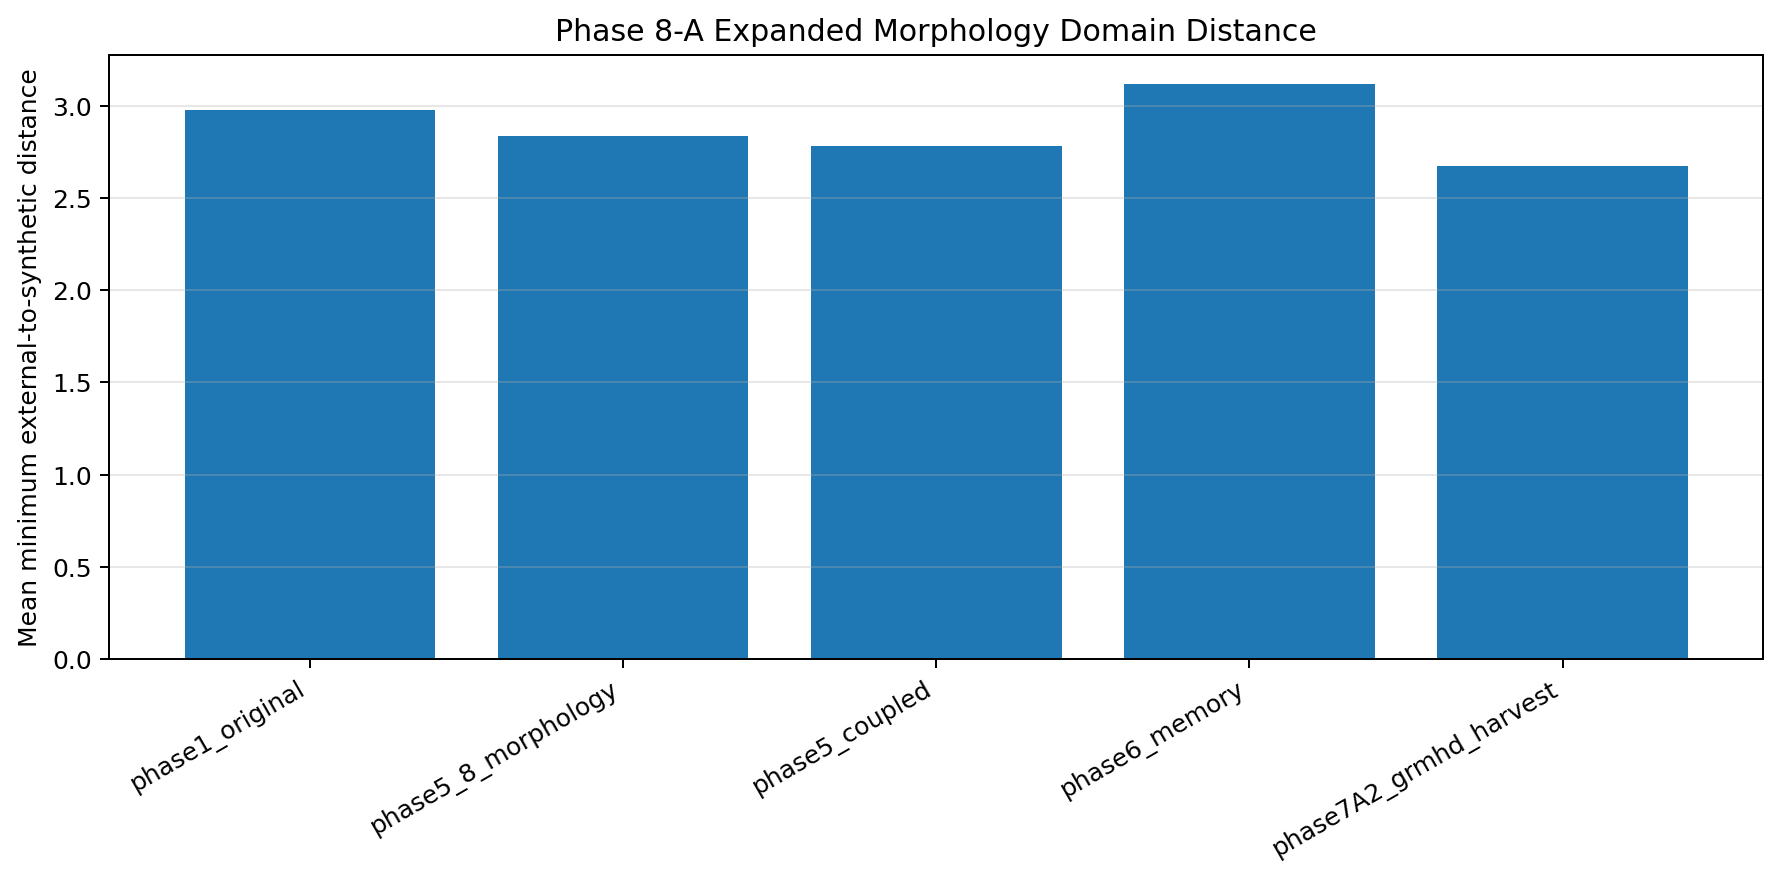


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase8A_morphology_domain_distance.png


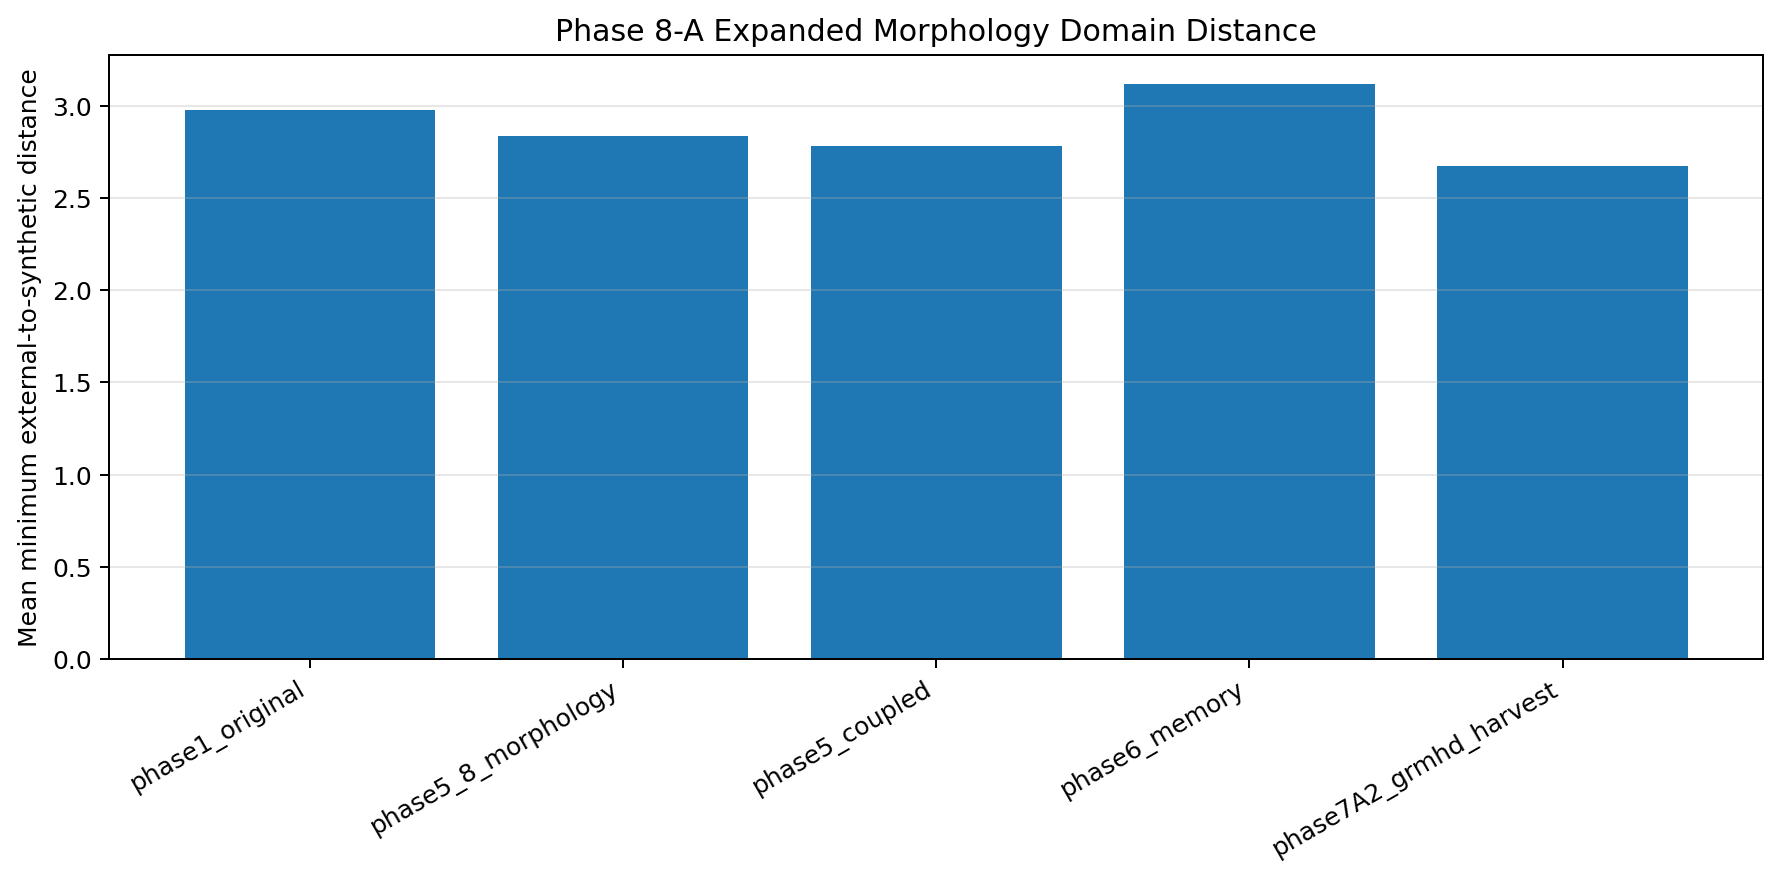


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/figures/phase8A_bridge_stability_tests.png


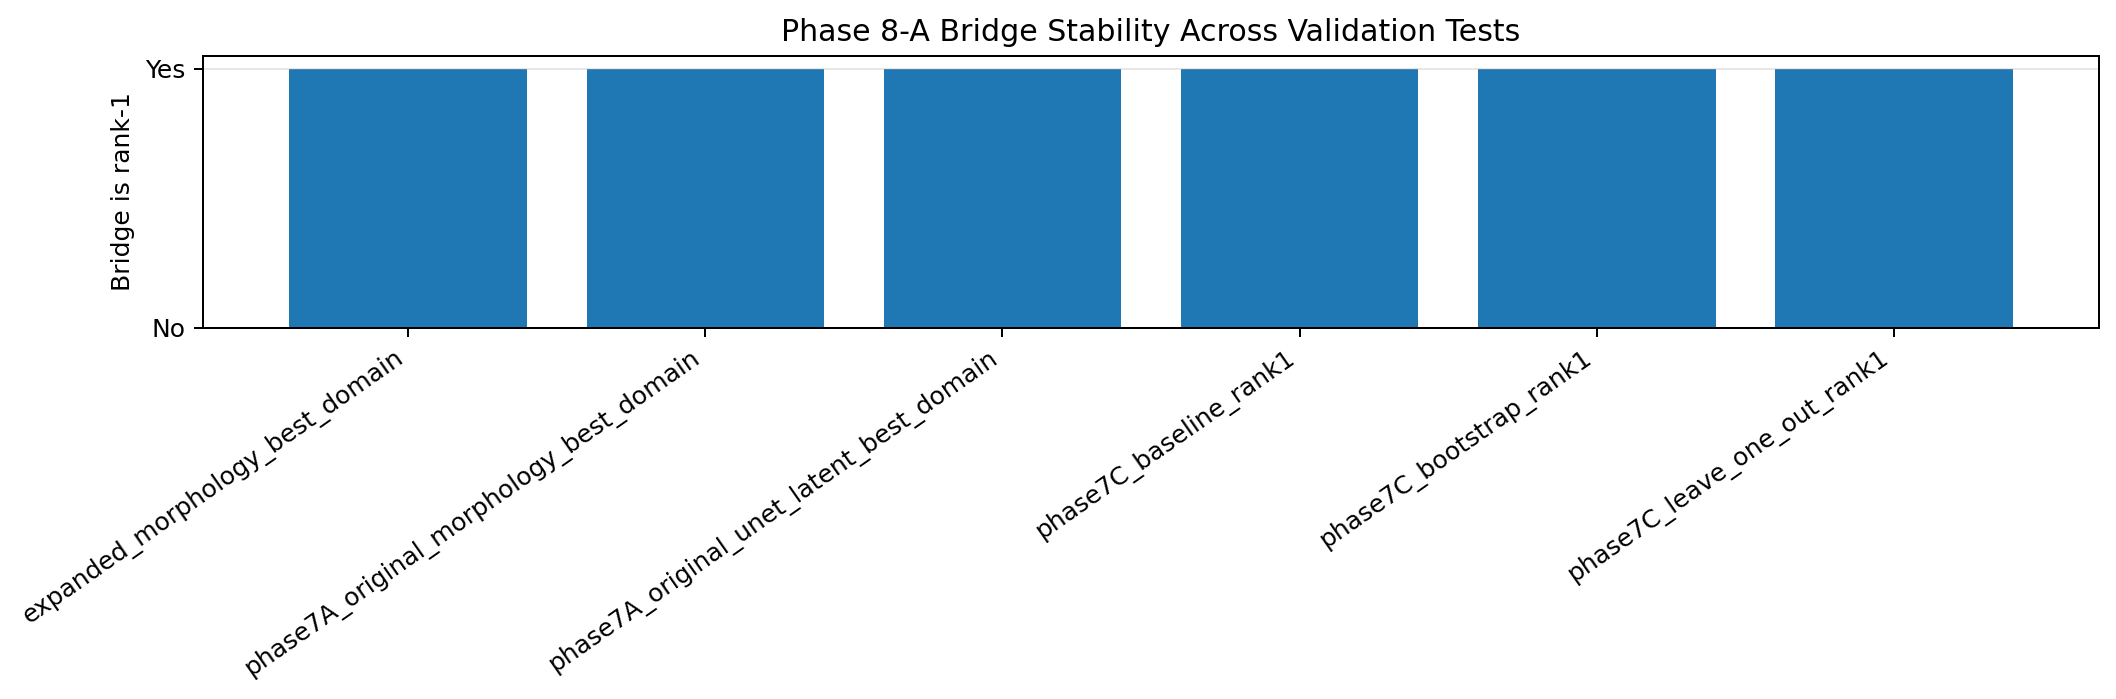


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase8A_bridge_stability_tests.png


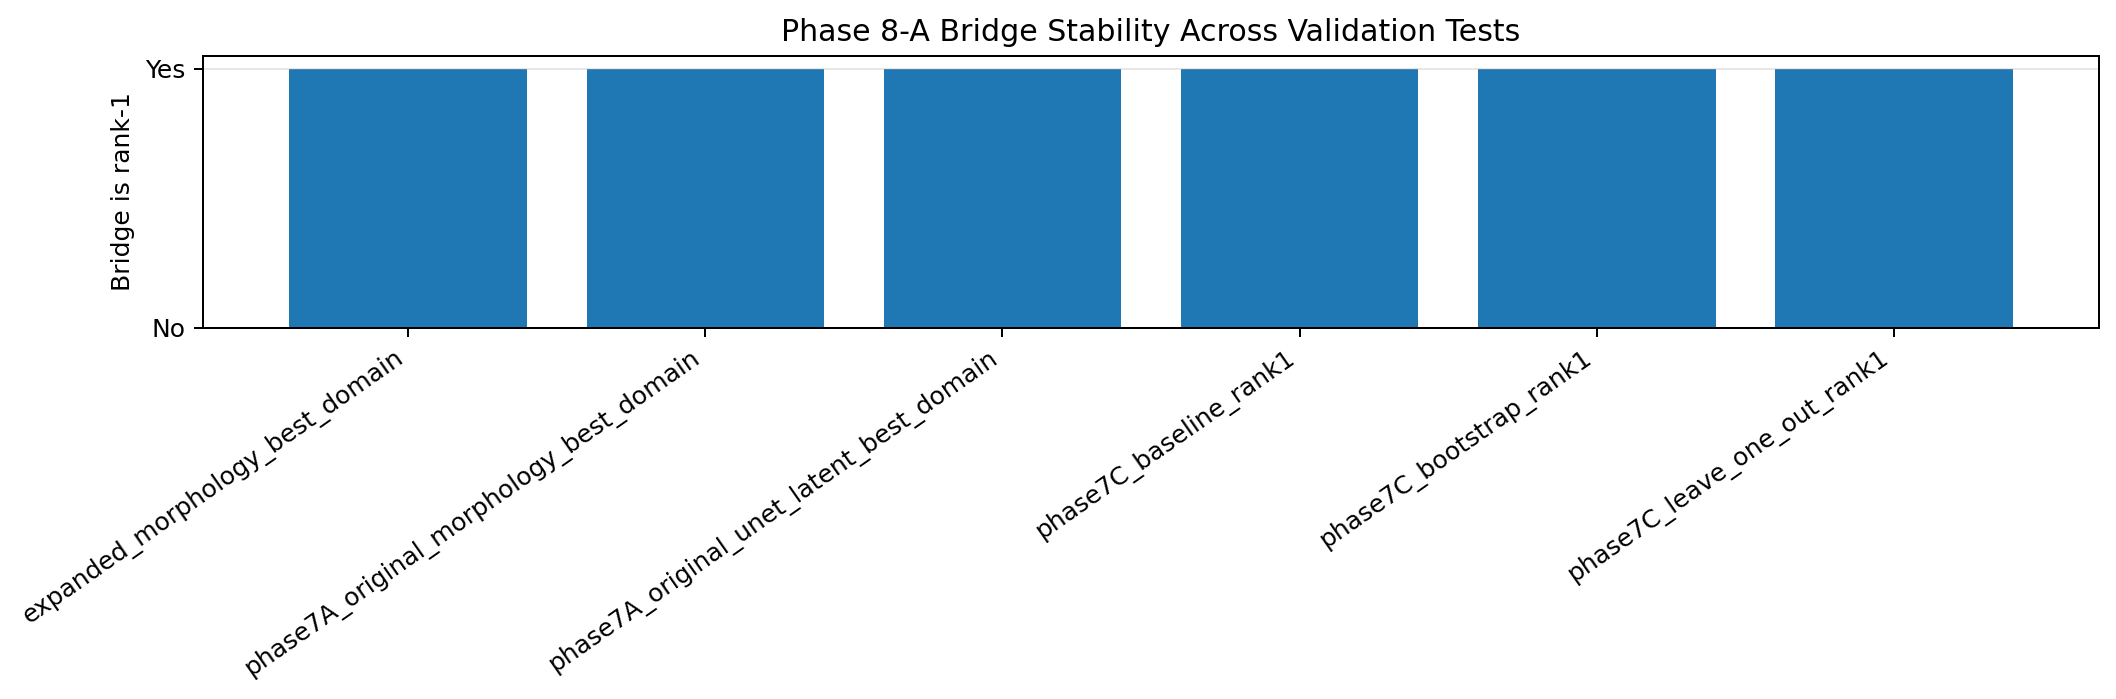


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/figures/phase8A_source_nearest_domain_distribution.png


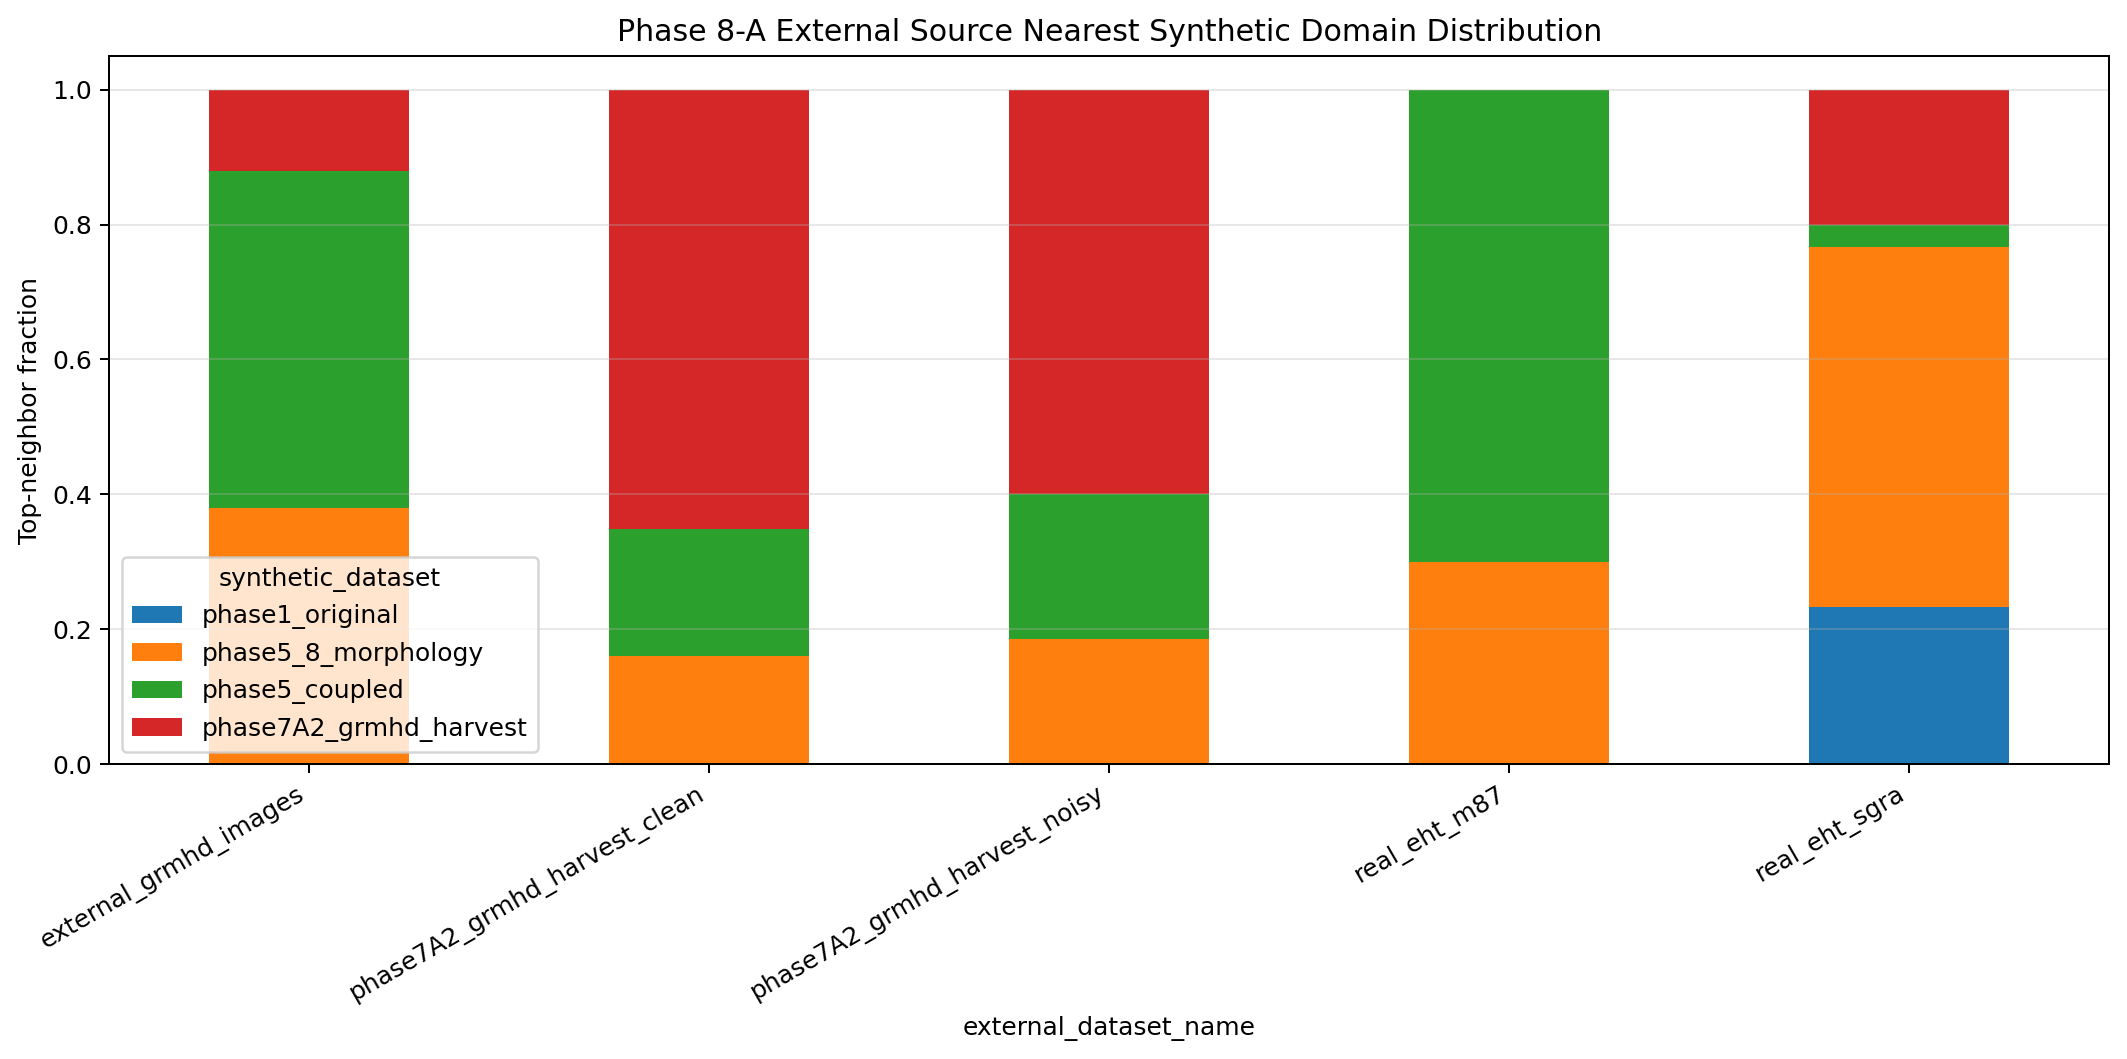


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase8A_source_nearest_domain_distribution.png


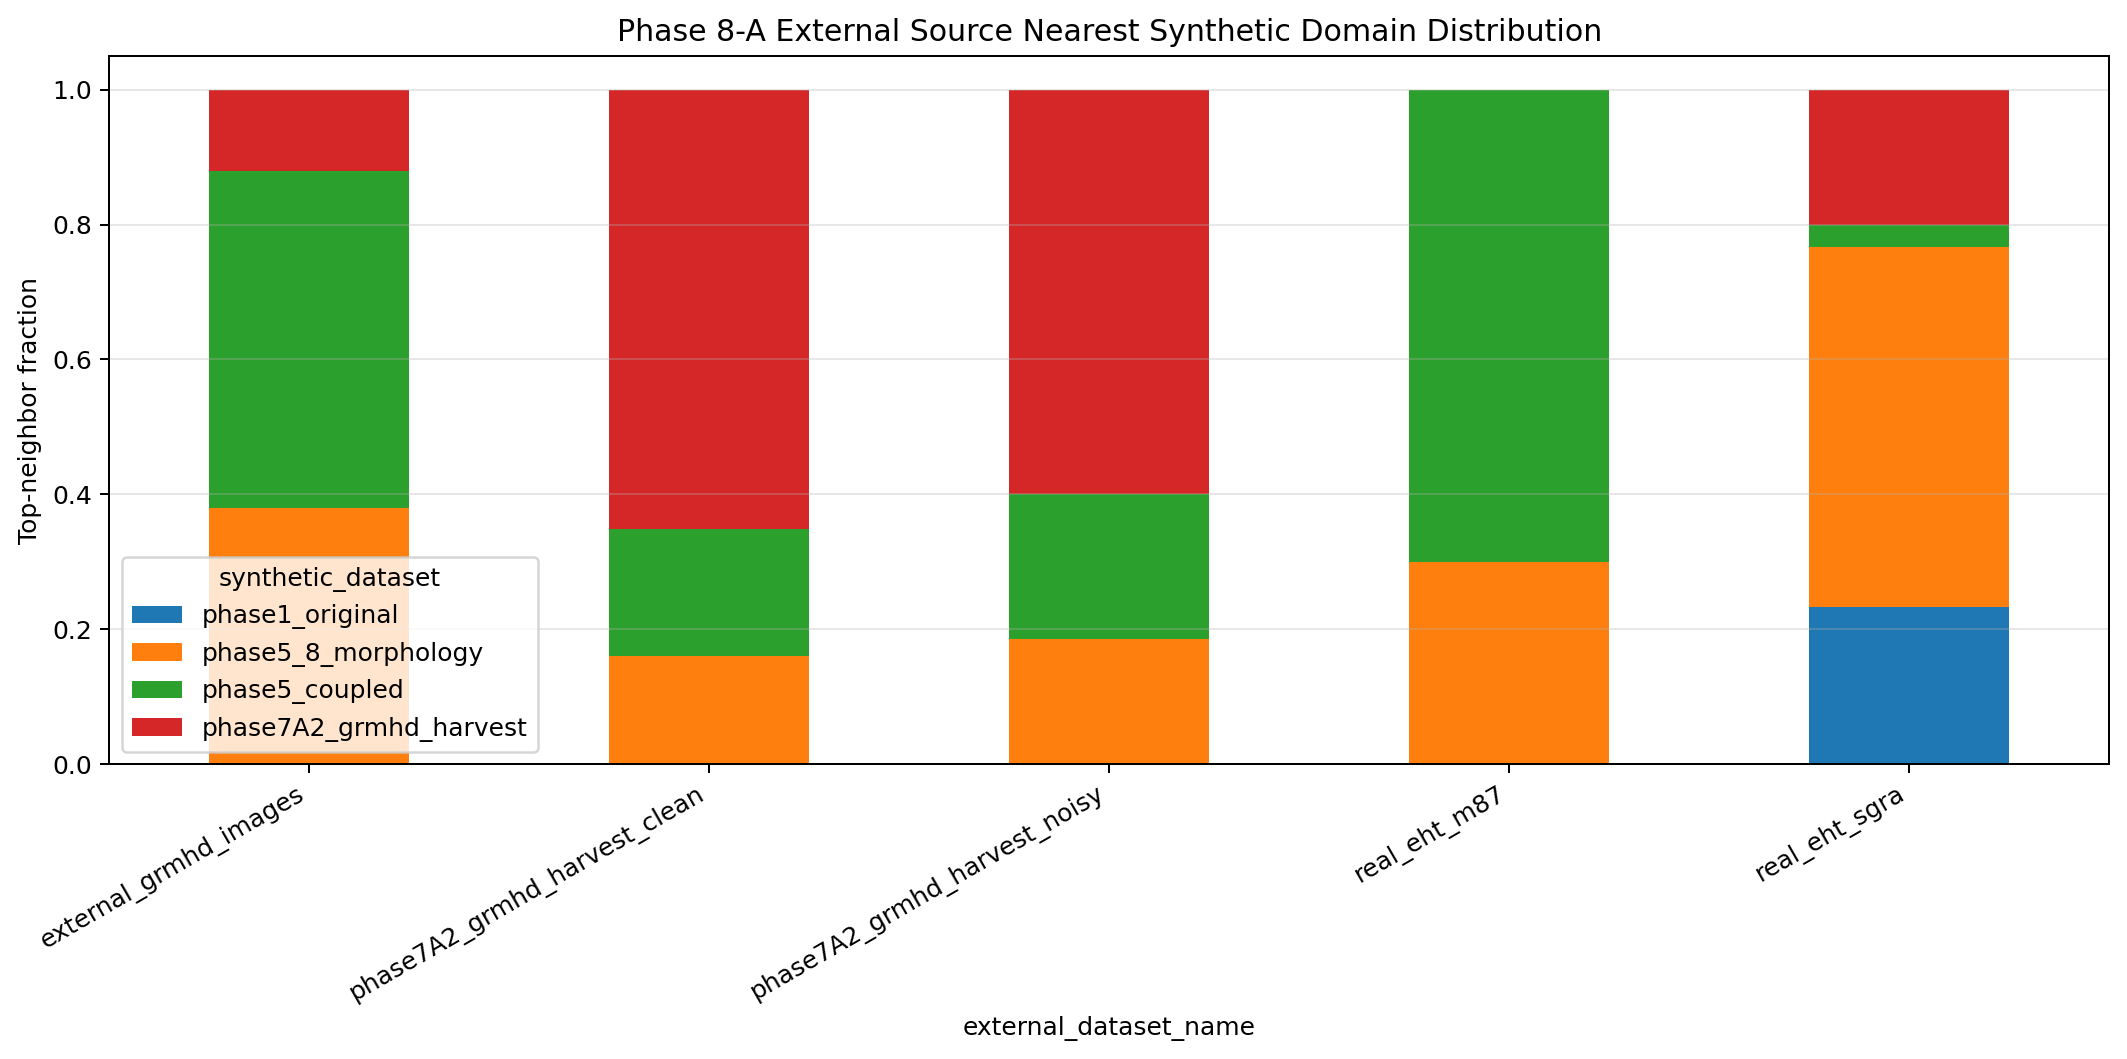


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/figures/phase8A_physical_proxy_summary.png


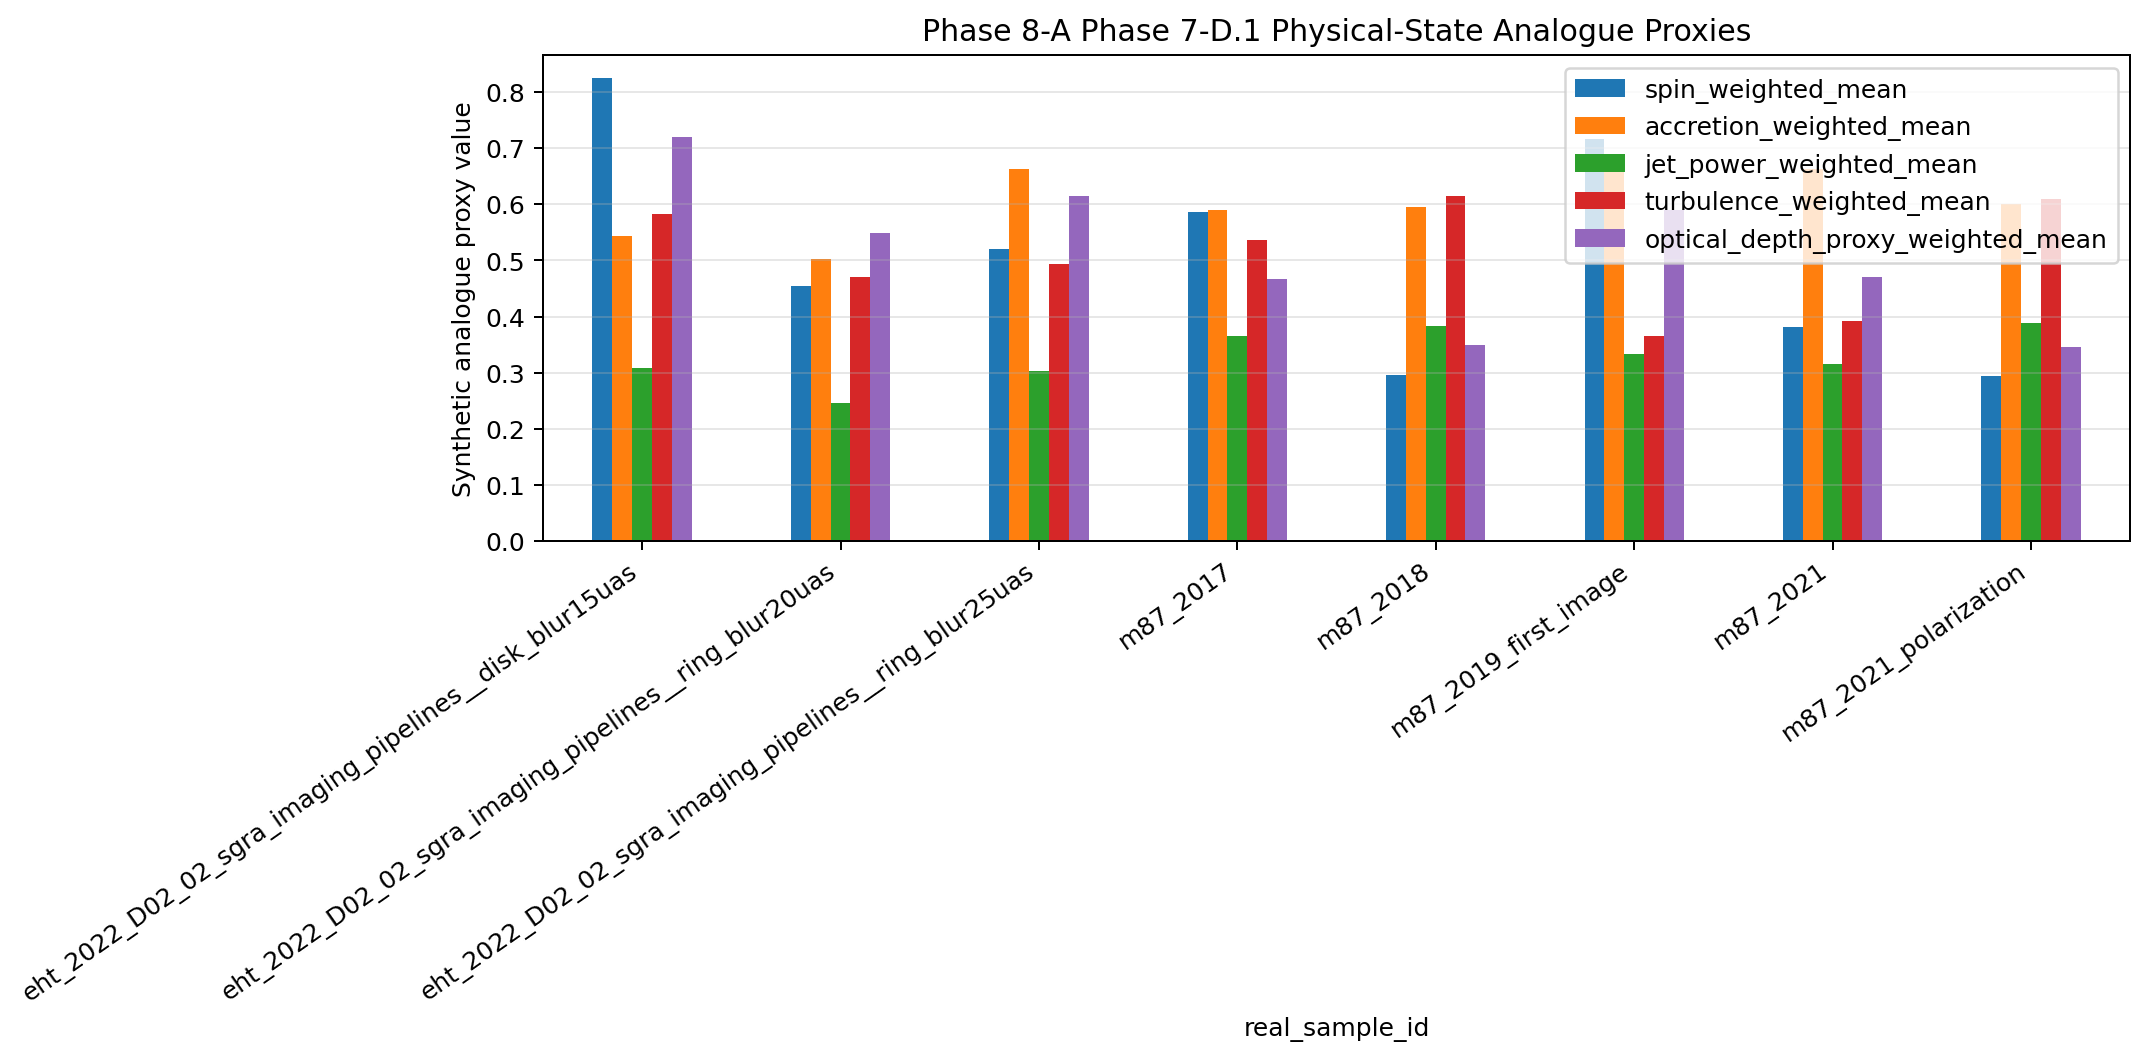


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase8A_physical_proxy_summary.png


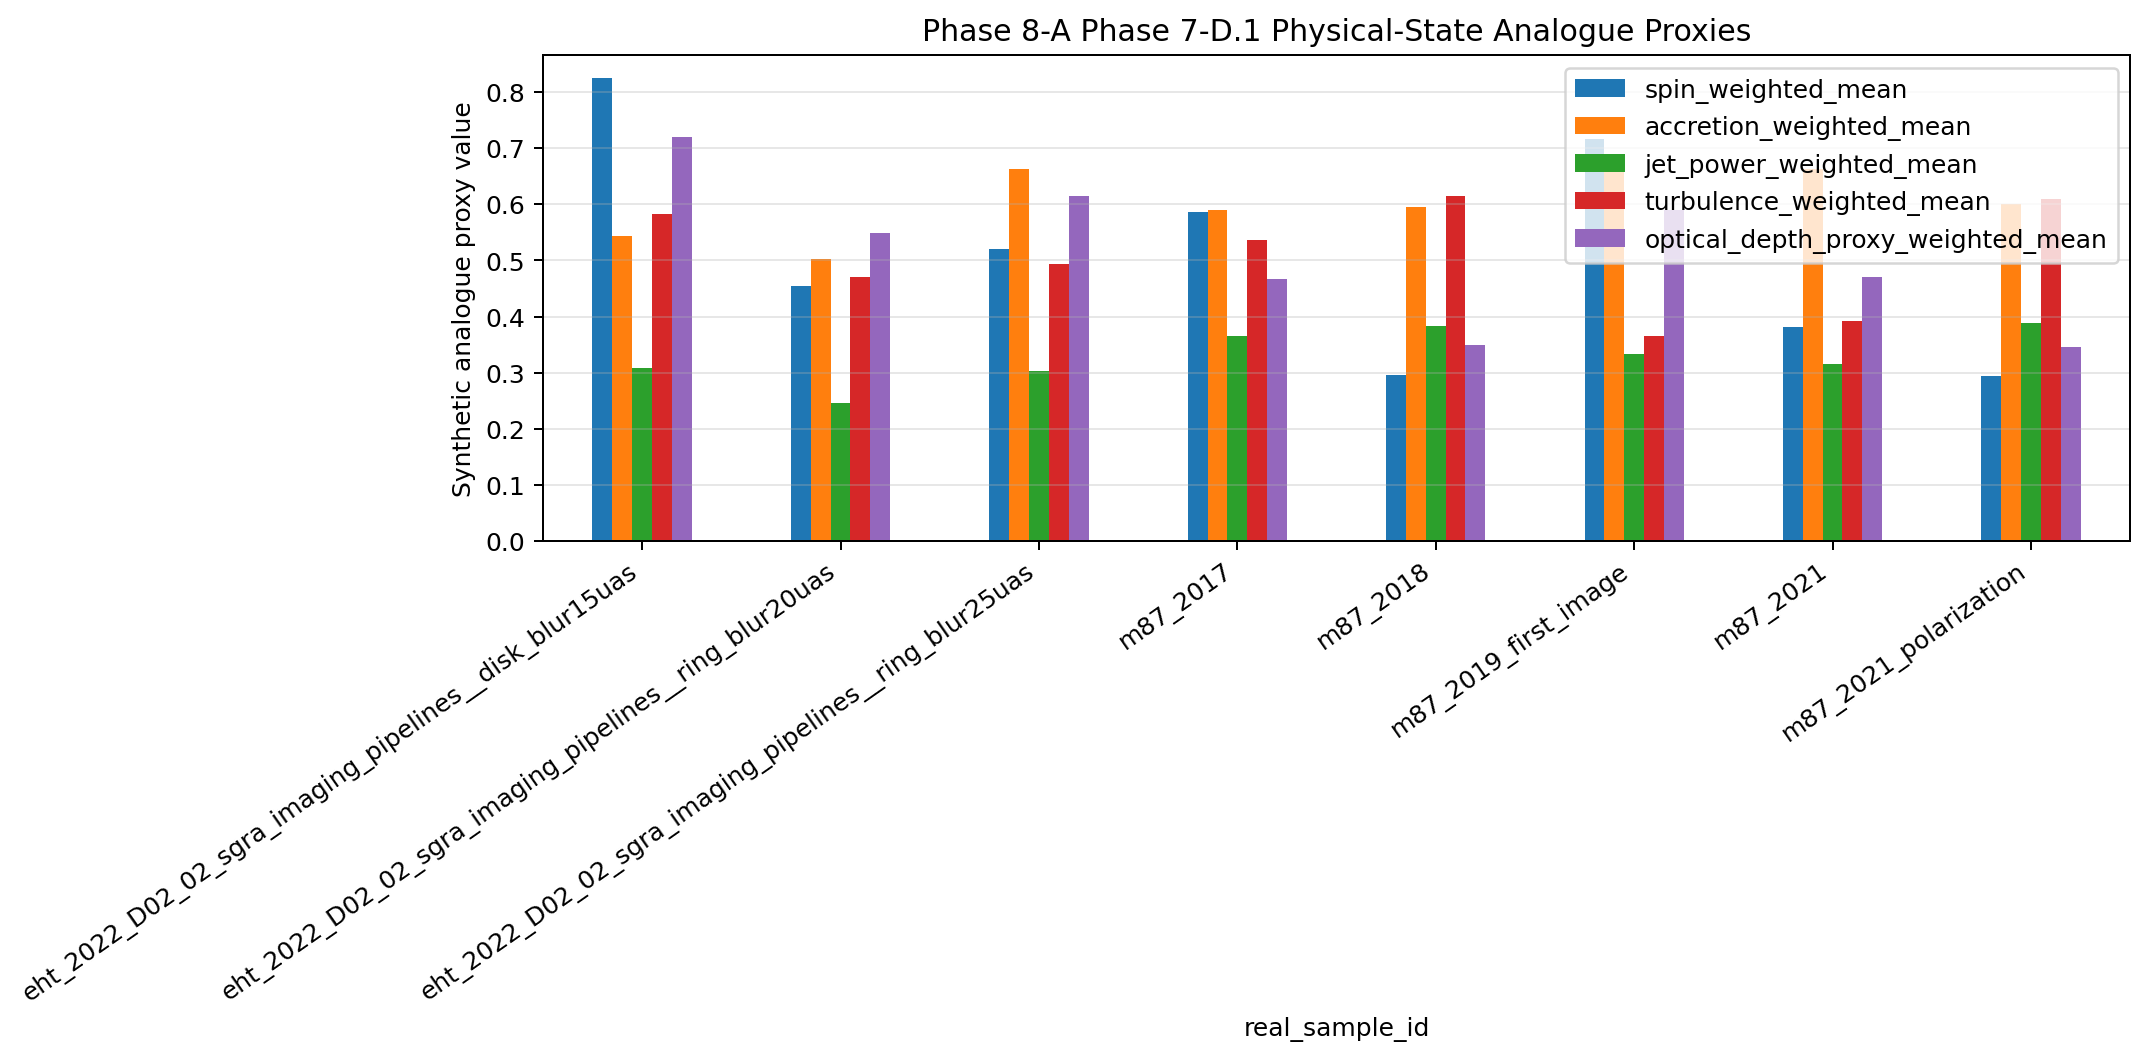


 /home/marwa/files/phase1_blackhole_generator/outputs/phase7C_calibration_robustness/figures/phase7C_robustness_distance_comparison.png


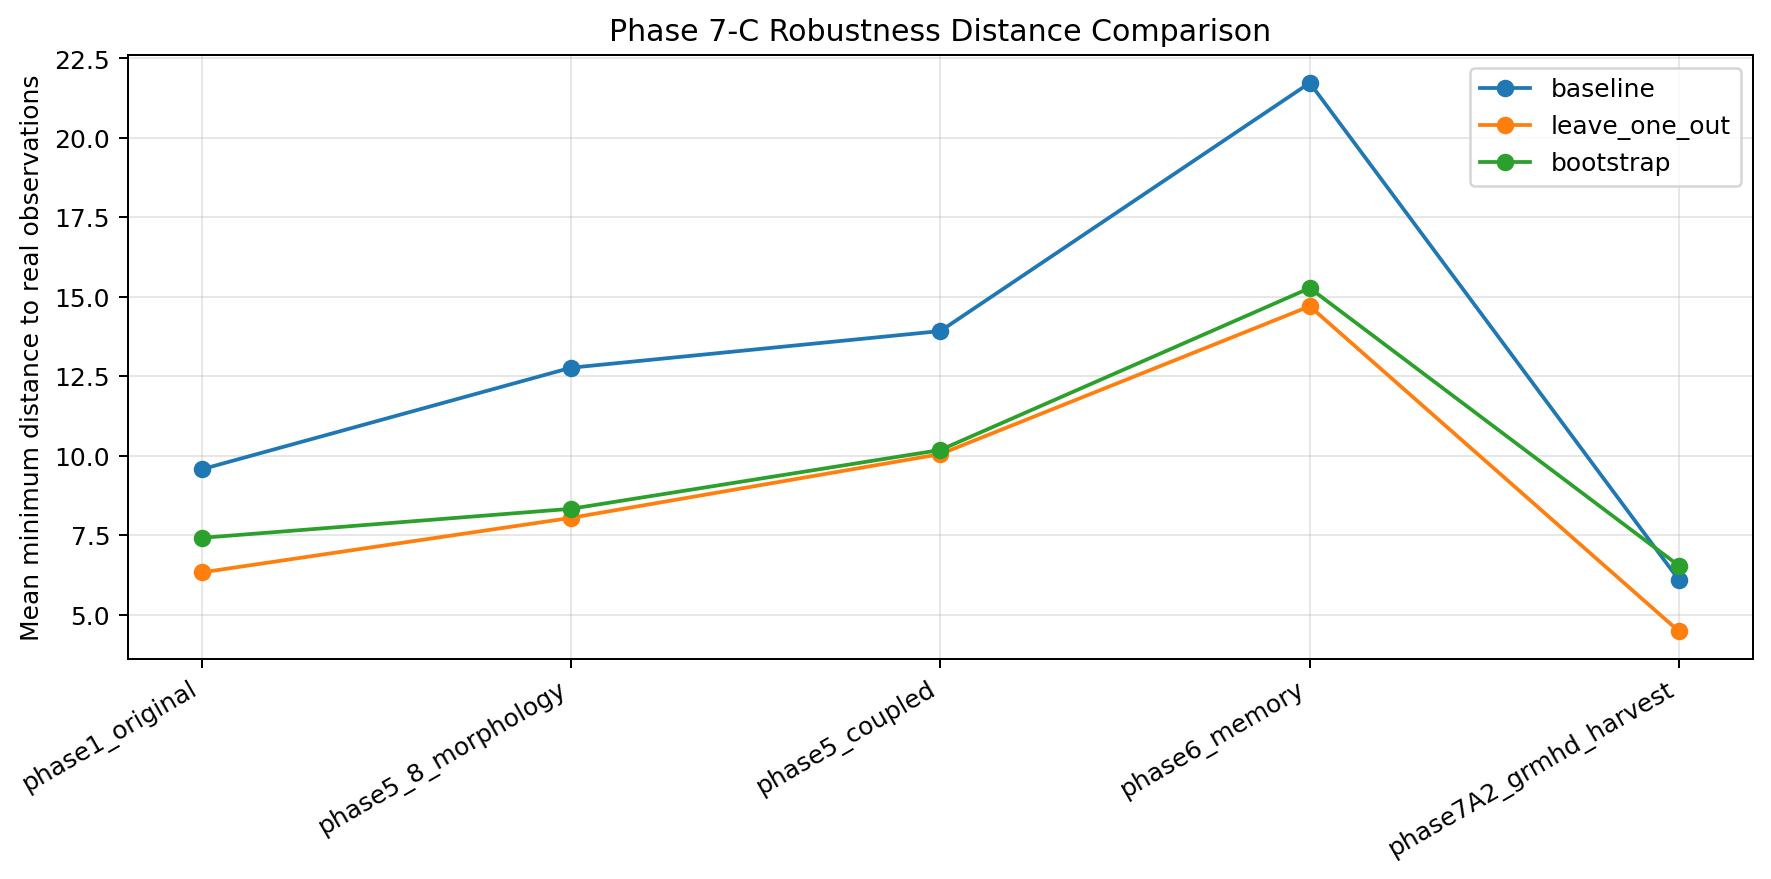


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase7C_robustness_distance_comparison.png


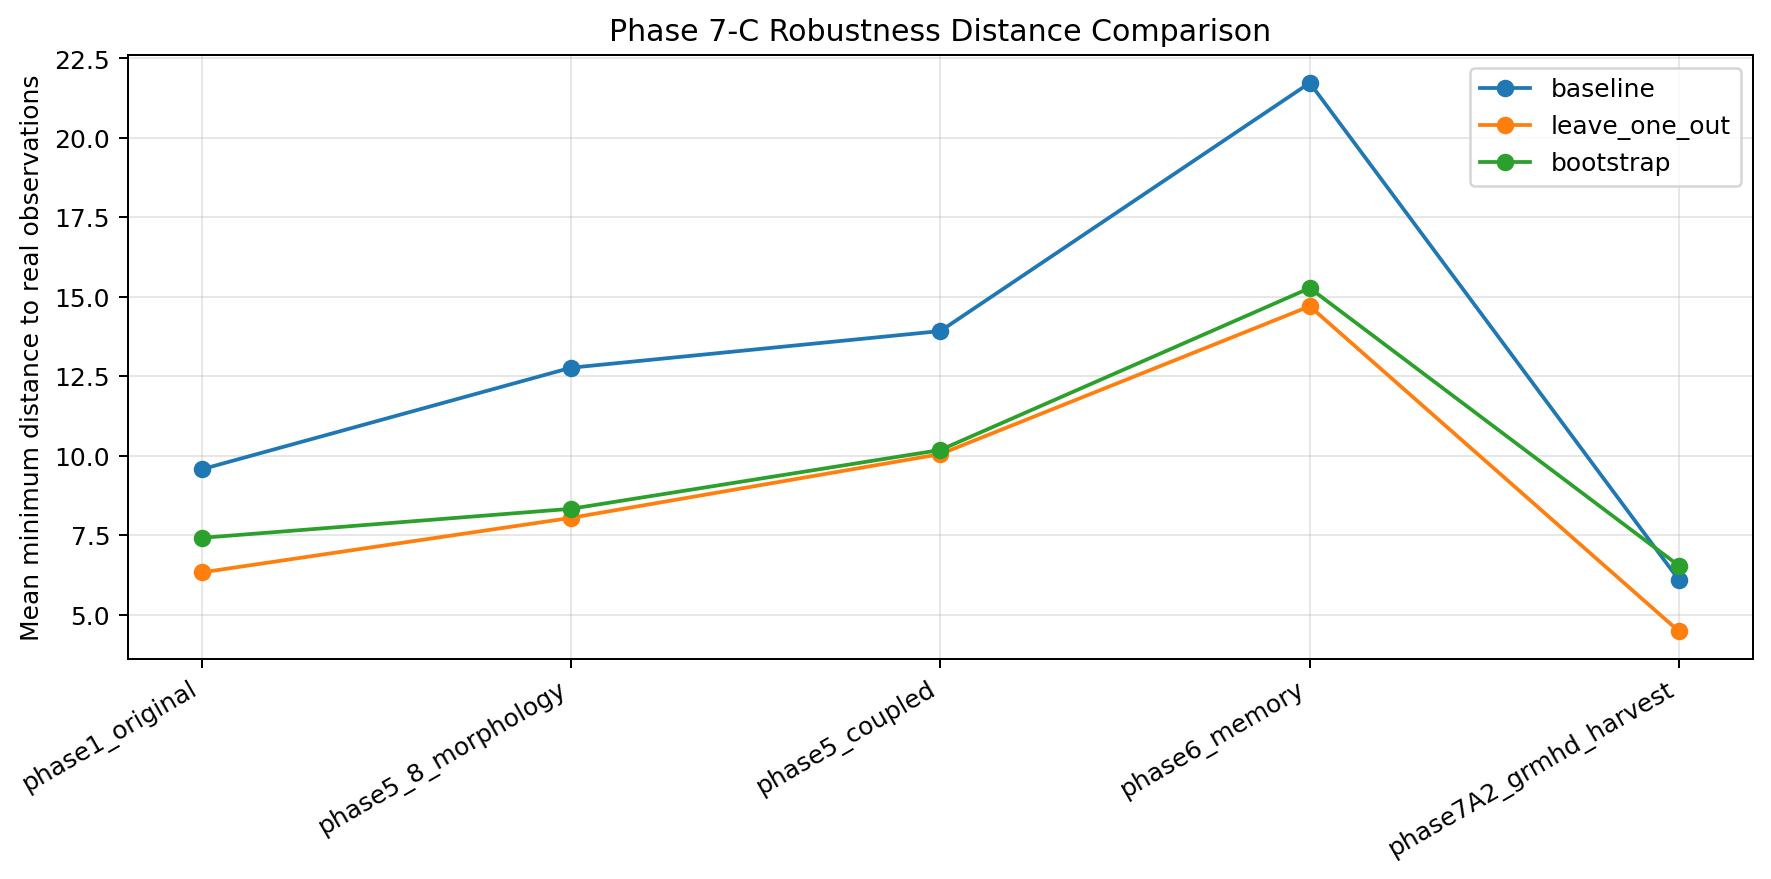


 /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/figures/phase7D1_physical_parameter_proxy_summary.png


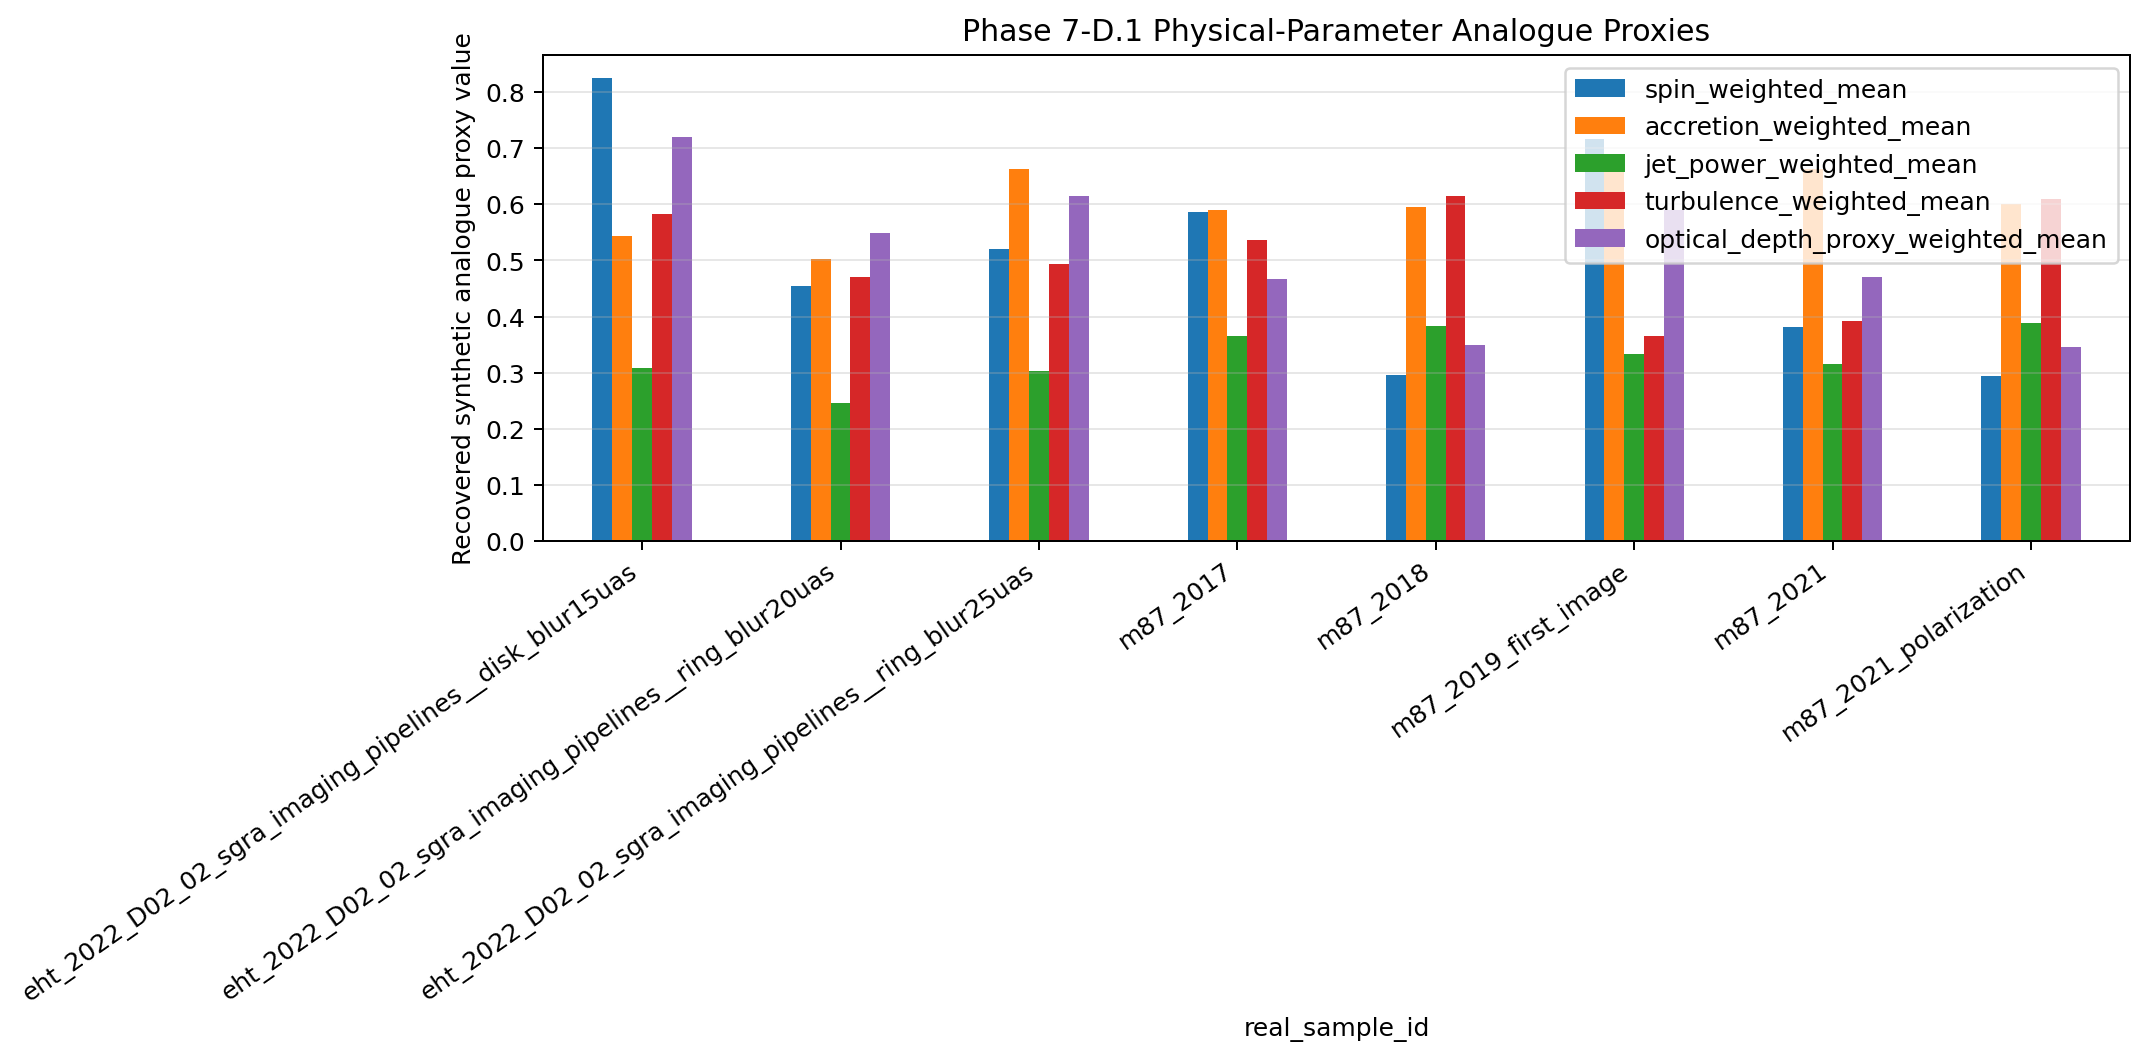


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase7D1_physical_parameter_proxy_summary.png


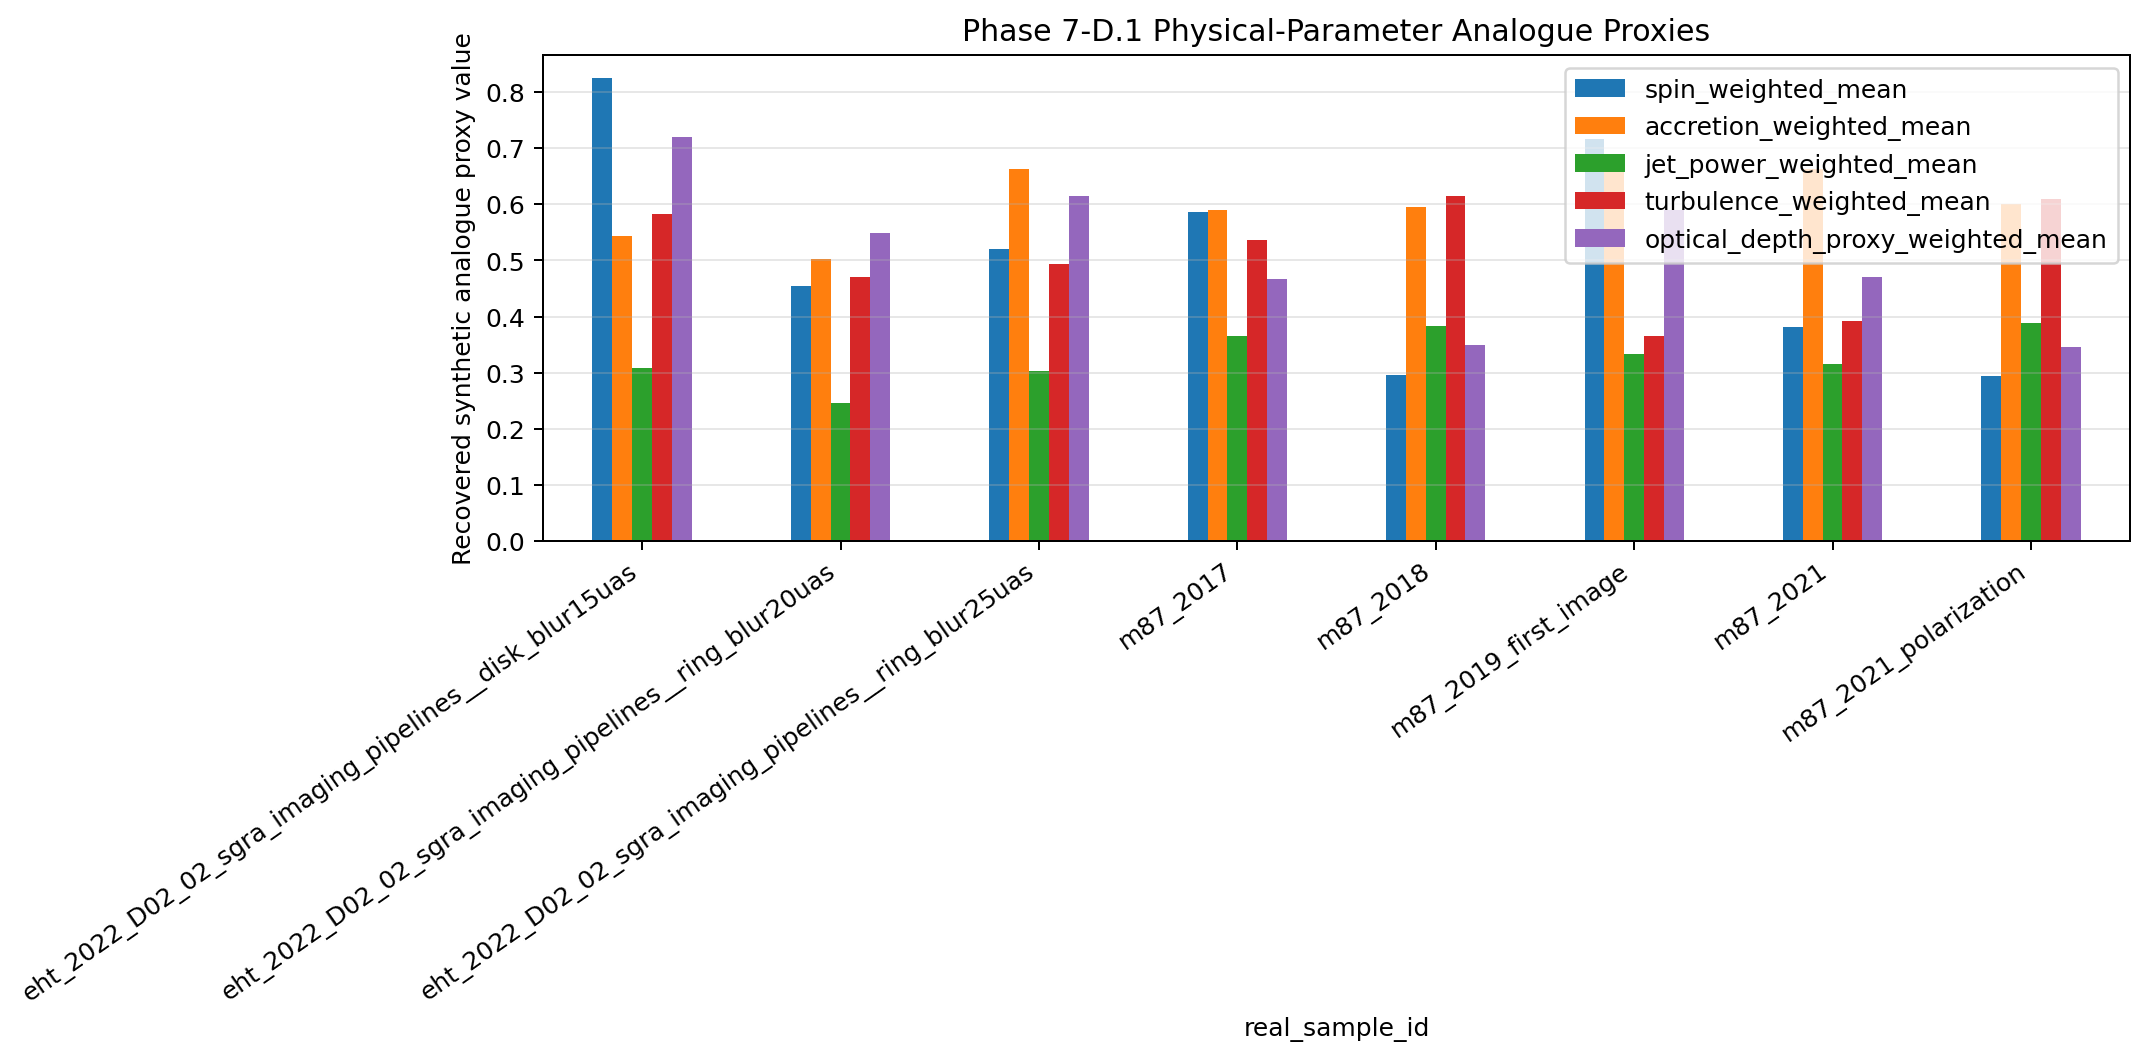


 /home/marwa/files/phase1_blackhole_generator/outputs/phase7D1_metadata_recovery_event_family_reconstruction/figures/phase7D1_reconstructed_memory_family_distribution.png


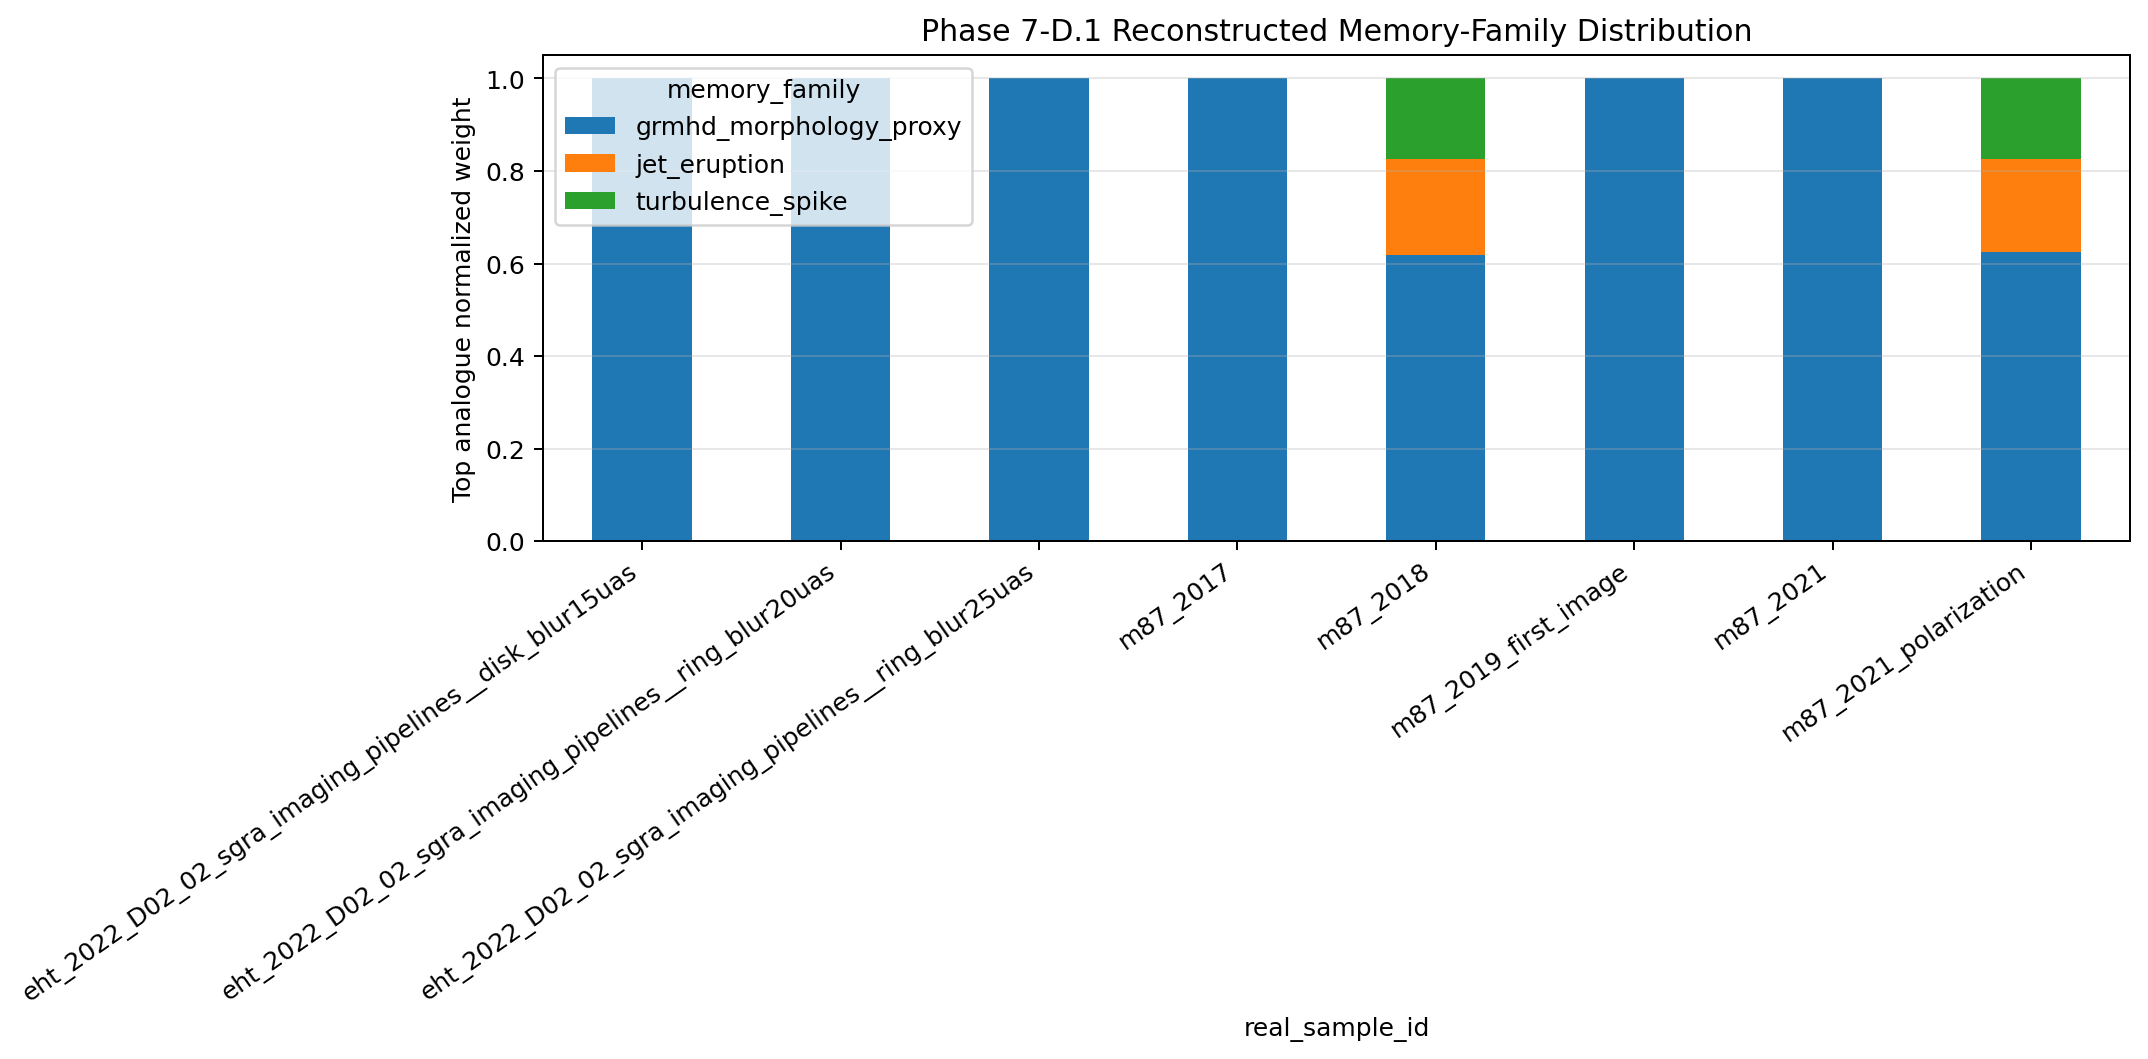


 /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/copied_key_assets/phase7D1_reconstructed_memory_family_distribution.png


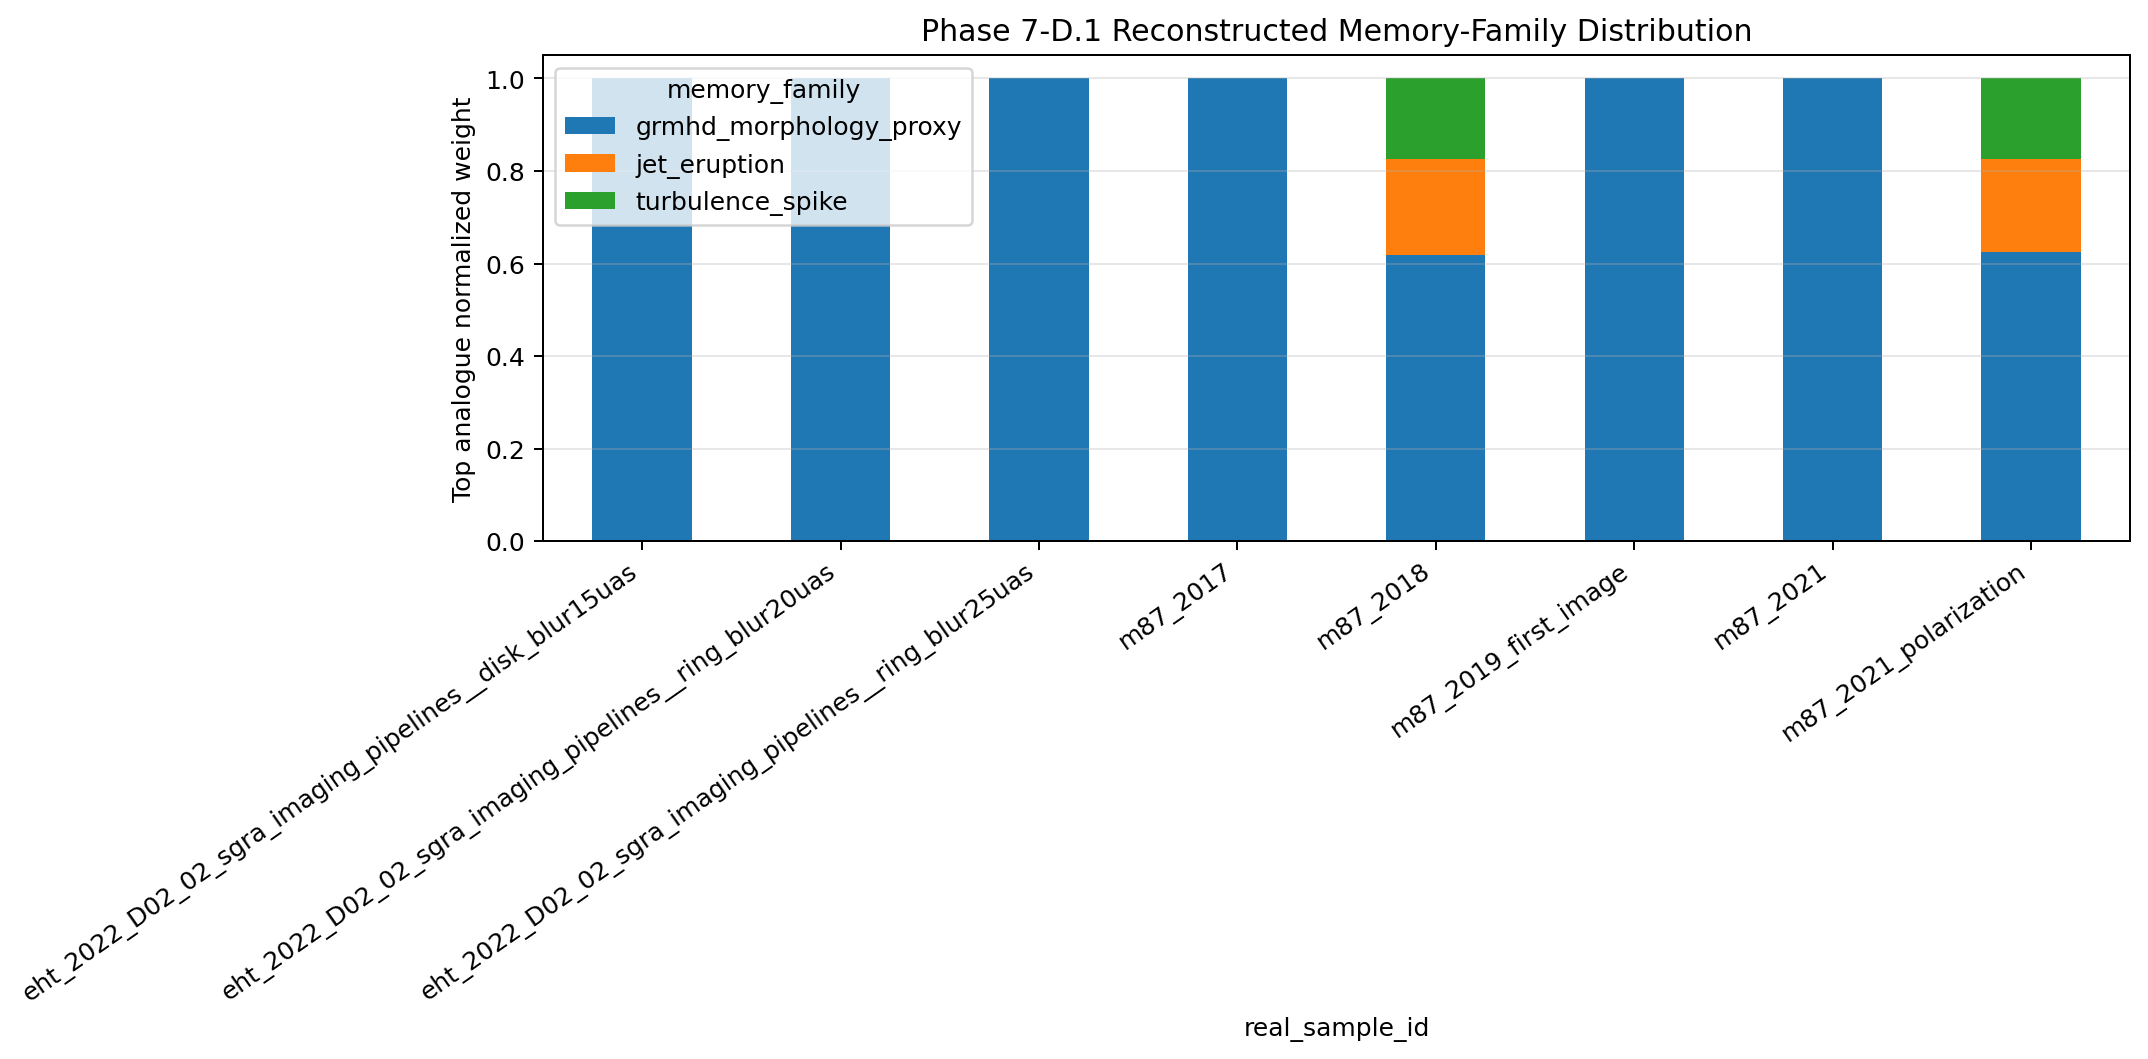


 /home/marwa/files/phase1_blackhole_generator/outputs/phase7D_calibrated_memory_mapping/figures/phase7D_analogue_confidence_scores.png


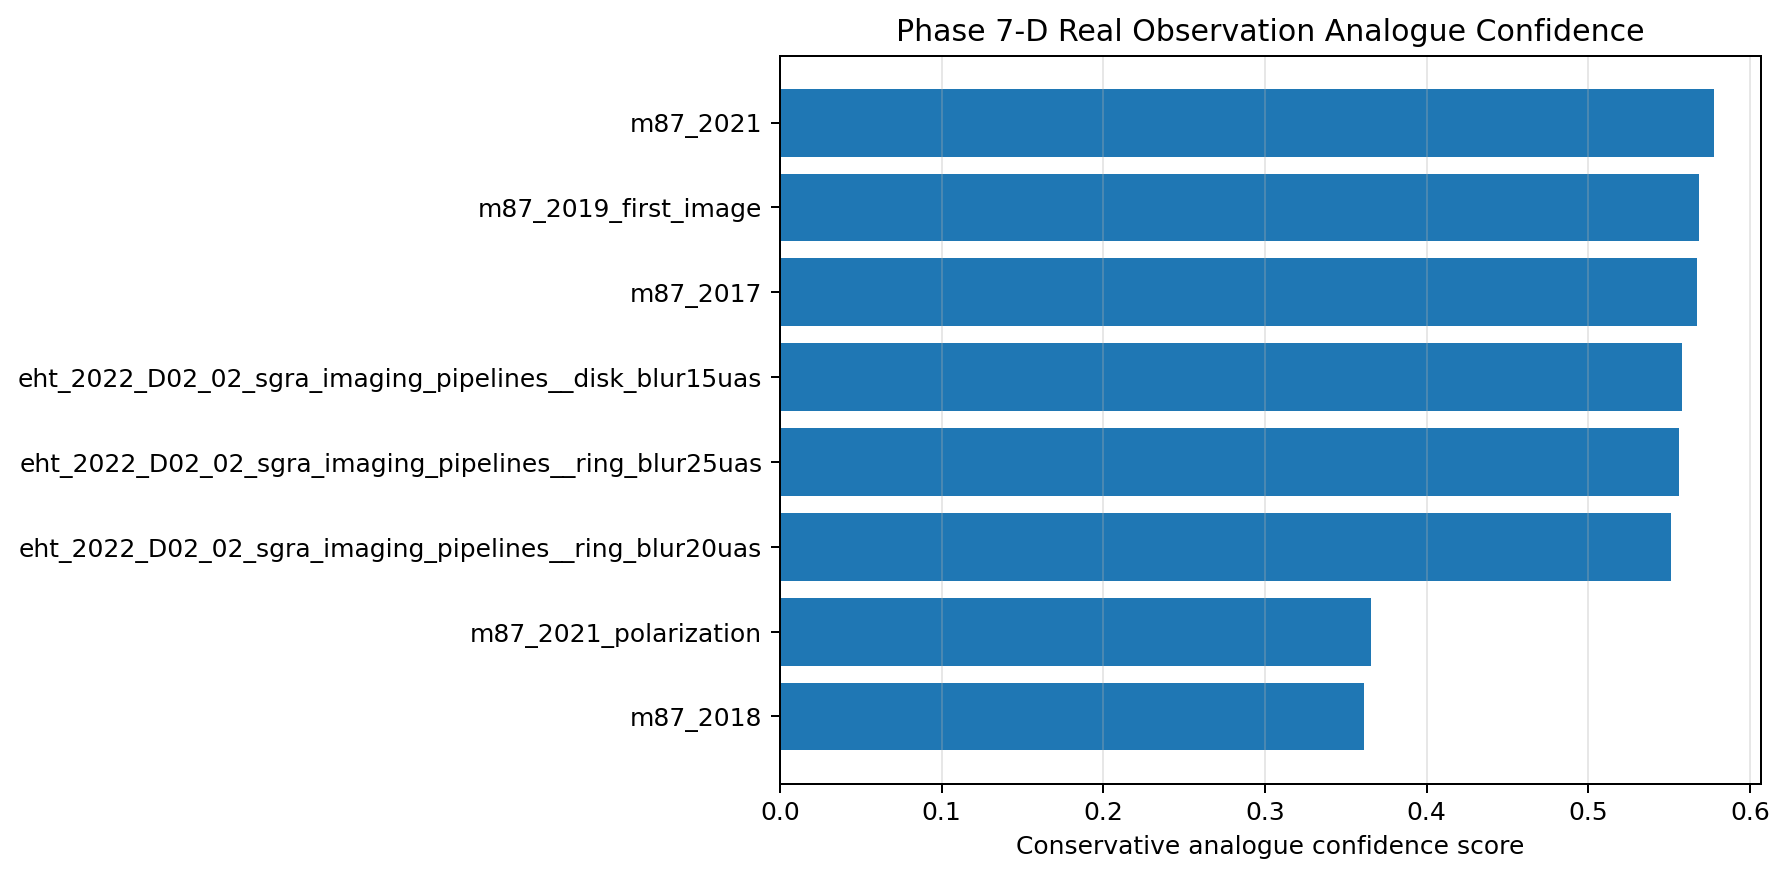

In [9]:
# ================================================================
# 9. Display selected high-value figures
# ================================================================

priority_keywords = [
    'phase8A_morphology_domain_distance',
    'phase8A_bridge_stability_tests',
    'phase8A_source_nearest_domain_distribution',
    'phase8A_physical_proxy_summary',
    'phase7C_robustness_distance_comparison',
    'phase7D1_physical_parameter_proxy_summary',
    'phase7D1_reconstructed_memory_family_distribution',
    'phase7D_analogue_confidence_scores',
    'phase7B_calibration_distance_comparison',
    'phase7A',
]

selected_figs = []
if len(figure_inventory_df):
    for kw in priority_keywords:
        matches = figure_inventory_df[figure_inventory_df['filename'].str.contains(kw, case=False, na=False)]
        for _, row in matches.head(2).iterrows():
            selected_figs.append(row['source_path'])

# Remove duplicates while preserving order.
seen = set()
selected_figs_unique = []
for p in selected_figs:
    if p not in seen:
        selected_figs_unique.append(p)
        seen.add(p)

print('Selected figures:', len(selected_figs_unique))
for p in selected_figs_unique[:15]:
    print('\n', p)
    try:
        display(IPImage(filename=p))
    except Exception as e:
        print('Could not display:', e)

## Part V — Final Tables for Thesis/Publication

This section builds compact final tables that can be pasted into a thesis chapter or paper draft.

In [10]:
# ================================================================
# 10. Final compact thesis tables
# ================================================================

# Table A: final validation chain
final_validation_chain_df = validation_scorecard_df.copy()
if len(final_validation_chain_df):
    final_validation_chain_df = final_validation_chain_df[[
        'validation_layer', 'test_type', 'best_domain', 'metric_name', 'metric_value', 'bridge_is_best', 'status'
    ]]

# Table B: final phase status
phase_status_rows = []
for _, r in timeline_df.iterrows():
    phase_status_rows.append({
        'phase': r['phase'],
        'name': r['name'],
        'status': r['status'],
        'scientific_role': r['scientific_role'],
    })
phase_status_df = pd.DataFrame(phase_status_rows)

# Table C: external validation inventory
external_inventory_df = loaded_tables.get('phase8A_external_source_audit')
if external_inventory_df is None:
    external_inventory_df = pd.DataFrame()

# Table D: final claim boundaries
claim_boundary_df = pd.DataFrame([
    {
        'claim_type': 'Supported',
        'claim': 'Real EHT/EHT-like observations consistently align most closely with a GRMHD-inspired synthetic bridge domain across available validation layers.',
        'basis': 'Phase 7-A, 7-C, and 8-A domain/ranking tests.',
    },
    {
        'claim_type': 'Supported',
        'claim': 'Structured synthetic-to-real latent calibration improves alignment between the synthetic bridge domain and real observations.',
        'basis': 'Phase 7-B ridge calibration and Phase 7-C robustness tests.',
    },
    {
        'claim_type': 'Supported',
        'claim': 'Calibrated analogue mapping can recover synthetic morphology-family and physical-state proxy descriptors for real observations.',
        'basis': 'Phase 7-D and Phase 7-D.1 analogue reconstruction tables.',
    },
    {
        'claim_type': 'Not supported',
        'claim': 'Direct recovery of true real black-hole accretion histories.',
        'basis': 'Real event histories are unknown and were not used as supervised labels.',
    },
    {
        'claim_type': 'Not supported',
        'claim': 'Reliable real event-age or memory-horizon reconstruction for M87* or Sgr A*.',
        'basis': 'Event-age metadata remains unavailable/insufficient for real analogue interpretation.',
    },
])

for name, df in {
    'final_thesis_table_validation_chain': final_validation_chain_df,
    'final_thesis_table_phase_status': phase_status_df,
    'final_thesis_table_external_inventory': external_inventory_df,
    'final_thesis_table_claim_boundaries': claim_boundary_df,
}.items():
    path = save_dataframe(df, name)
    print('Saved:', path)
    display(df.head(20))

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_thesis_table_validation_chain.csv


,validation_layer,test_type,best_domain,metric_name,metric_value,bridge_is_best,status
0,Phase 7-A morphology,domain distance,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,2.472881,True,pass
1,Phase 7-A unet_latent,domain distance,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,6.081075,True,pass
2,Phase 7-C baseline,robustness ranking,phase7A2_grmhd_harvest,ranking_distance,6.081075,True,pass
3,Phase 7-C bootstrap,robustness ranking,phase7A2_grmhd_harvest,ranking_distance,6.531777,True,pass
4,Phase 7-C leave_one_out,robustness ranking,phase7A2_grmhd_harvest,ranking_distance,4.468646,True,pass
5,Phase 8-A expanded morphology,expanded domain distance,phase7A2_grmhd_harvest,mean_min_distance_external_to_synthetic,2.672039,True,pass


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_thesis_table_phase_status.csv


,phase,name,status,scientific_role
0,Phase 1,Synthetic Black Hole Universe,completed,Creates the controlled universe where ground t...
1,Phase 2,Observation Reconstruction,completed,Preserves image structure needed for later mem...
2,Phase 4,Physical Parameter Recovery,exploratory completed,Revealed limits of direct parameter inference ...
3,Phase 5,Physics-to-Image Coupling,completed,Makes synthetic images more morphologically in...
4,Phase 6,Static Memory Persistence,completed,Introduces observational memory and memory per...
5,Phase 6-T,Late Temporal Observation,completed,Shows late temporal information has limited re...
6,Phase 6-U,Event-Centered Observation,completed,Shows event identity is far more recoverable t...
7,Phase 7-A,Real Observation Consistency Study,completed,Identifies the GRMHD-inspired bridge domain as...
8,Phase 7-A.2,GRMHD Image Harvesting,completed,Supplies the bridge domain later validated acr...
9,Phase 7-B,Synthetic-to-Real Latent Calibration,completed,Shows structured calibration substantially imp...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_thesis_table_external_inventory.csv


,source_group,dataset_name,path,exists,description,n_image_files,n_data_products,preview_images,preview_data_products
0,real_eht,real_eht_m87,/home/marwa/files/phase1_blackhole_generator/d...,True,M87* EHT or EHT-like event-horizon-scale images,5,0,m87_2017.png; m87_2018.png; m87_2019_first_ima...,NaN
1,real_eht,real_eht_sgra,/home/marwa/files/phase1_blackhole_generator/d...,True,Sagittarius A* EHT or EHT-like event-horizon-s...,3,0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,NaN
2,real_external,real_external_misc,/home/marwa/files/phase1_blackhole_generator/d...,True,Other real or external black-hole observation ...,0,0,NaN,NaN
3,grmhd_proxy,phase7A2_grmhd_harvest_clean,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy clean images,1206,0,grmhd_ext_00001.png; grmhd_ext_00002.png; grmh...,NaN
4,grmhd_proxy,phase7A2_grmhd_harvest_noisy,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy noisy images,1206,0,grmhd_ext_00001_noisy.png; grmhd_ext_00002_noi...,NaN
5,external_grmhd,external_grmhd_images,/home/marwa/files/phase1_blackhole_generator/d...,True,User-supplied rendered GRMHD images,10,0,ehtim_rowan_m87_closure_blur_clean_beam.png; e...,NaN
6,raw_grmhd,raw_grmhd_products,/home/marwa/files/phase1_blackhole_generator/d...,True,Raw GRMHD data products such as HDF5/FITS snap...,0,0,NaN,NaN


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables/final_thesis_table_claim_boundaries.csv


,claim_type,claim,basis
0,Supported,Real EHT/EHT-like observations consistently al...,"Phase 7-A, 7-C, and 8-A domain/ranking tests."
1,Supported,Structured synthetic-to-real latent calibratio...,Phase 7-B ridge calibration and Phase 7-C robu...
2,Supported,Calibrated analogue mapping can recover synthe...,Phase 7-D and Phase 7-D.1 analogue reconstruct...
3,Not supported,Direct recovery of true real black-hole accret...,Real event histories are unknown and were not ...
4,Not supported,Reliable real event-age or memory-horizon reco...,Event-age metadata remains unavailable/insuffi...


In [11]:
# ================================================================
# 11. Optional Excel workbook export
# ================================================================

workbook_path = FINAL_DIR / 'Final_Project_Synthesis_Tables.xlsx'
excel_status = 'not attempted'

try:
    with pd.ExcelWriter(workbook_path, engine='openpyxl') as writer:
        timeline_df.to_excel(writer, sheet_name='phase_timeline', index=False)
        table_inventory_df.to_excel(writer, sheet_name='table_inventory', index=False)
        figure_inventory_df.to_excel(writer, sheet_name='figure_inventory', index=False)
        validation_scorecard_df.to_excel(writer, sheet_name='validation_scorecard', index=False)
        validation_summary_df.to_excel(writer, sheet_name='validation_summary', index=False)
        phase_status_df.to_excel(writer, sheet_name='phase_status', index=False)
        claim_boundary_df.to_excel(writer, sheet_name='claim_boundaries', index=False)
        if phase8A_status_df is not None:
            phase8A_status_df.to_excel(writer, sheet_name='phase8A_status', index=False)
        if phase8A_criteria_df is not None:
            phase8A_criteria_df.to_excel(writer, sheet_name='phase8A_criteria', index=False)
        if external_inventory_df is not None and len(external_inventory_df):
            external_inventory_df.to_excel(writer, sheet_name='external_inventory', index=False)
    excel_status = f'saved: {workbook_path}'
except ModuleNotFoundError as e:
    excel_status = f'openpyxl missing, skipped Excel export: {e}'
except Exception as e:
    excel_status = f'Excel export failed: {e}'

print(excel_status)

openpyxl missing, skipped Excel export: No module named 'openpyxl'


## Part VI — Final Scientific Synthesis

This section generates a final Markdown and plain-text report containing the complete high-level research narrative.

In [12]:
# ================================================================
# 12. Generate final synthesis report
# ================================================================

created_at = datetime.now().isoformat()

phase8_status_text = df_to_text(phase8A_status_df, max_rows=10)
validation_text = df_to_text(validation_scorecard_df, max_rows=30)
claim_text = df_to_text(claim_boundary_df, max_rows=20)
external_text = df_to_text(external_inventory_df, max_rows=20)
phase_text = df_to_text(timeline_df[['phase', 'name', 'status', 'scientific_role']], max_rows=30)

if len(validation_summary_df):
    bridge_consistency_score = validation_summary_df['bridge_consistency_score'].iloc[0]
else:
    bridge_consistency_score = np.nan

final_report = f"""
# Final Project Synthesis — Black Hole Observational Memory Project

Created: {created_at}

## Project Thesis

This project studies whether black-hole observations can behave as memory-bearing systems: whether current or near-current observations retain recoverable information about prior physical events.

The project evolved from synthetic image generation and parameter recovery into a broader observational-memory framework spanning synthetic datasets, temporal memory experiments, GRMHD-inspired bridge domains, real EHT observations, and expanded external validation.

## Phase 1–8 Timeline

{phase_text}

## Final Validation Chain

{validation_text}

Bridge consistency score:

{bridge_consistency_score}

## Phase 8-A Final Status

{phase8_status_text}

## External Validation Inventory

{external_text}

## Main Scientific Finding

The strongest defensible conclusion is:

Real EHT/EHT-like observations consistently occupy regions of morphology and latent space most closely associated with the GRMHD-inspired Phase 7-A.2 synthetic bridge domain. This relationship survives domain-distance testing, latent-space comparison, structured calibration, leave-one-real-out robustness, bootstrap robustness, analogue mapping, metadata reconstruction, and Phase 8-A expanded validation.

## Claim Boundaries

{claim_text}

## Interpretation

The project supports an observational-memory framework in which synthetic black-hole event histories produce morphology signatures that can be compared with more realistic and real observational domains.

The project does not claim that true historical accretion events of real black holes have been recovered. Instead, it establishes a calibrated analogue-mapping framework: real observations can be mapped to synthetic morphology families and physical-state proxy descriptors under controlled assumptions.

## Key Achievements

1. Built a controlled synthetic black-hole universe with known event histories.
2. Demonstrated that event identity is more recoverable than event timing.
3. Established the Phase 7-A.2 GRMHD-inspired bridge domain.
4. Showed that the bridge domain is closest to real EHT observations in morphology and latent spaces.
5. Demonstrated synthetic-to-real latent calibration.
6. Tested robustness through leave-one-real-out and bootstrap validation.
7. Recovered synthetic physical-state proxy descriptors for real-observation analogues.
8. Added independent EHT-imaging products and achieved Phase 8-A PASS status.

## Remaining Limitations

1. Real black-hole historical labels are unavailable.
2. Event-age reconstruction remains unsupported for real observations.
3. External GRMHD validation is stronger than before but still small compared with ideal astrophysical simulation libraries.
4. Some GRMHD-style images are EHT-imaging reconstructions or model-derived products, not full independent GRMHD simulation ensembles.

## Final Recommendation

Stop adding modeling phases for now. The project has reached a coherent research endpoint. The next high-value deliverable is a manuscript or thesis results chapter based on the final synthesis, with conservative wording around synthetic analogue mapping rather than real-history recovery.
"""

report_md_path = FINAL_REPORT_DIR / 'Final_Project_Synthesis_Report.md'
report_txt_path = FINAL_REPORT_DIR / 'Final_Project_Synthesis_Report.txt'

with open(report_md_path, 'w') as f:
    f.write(final_report)
with open(report_txt_path, 'w') as f:
    f.write(final_report)

print('Saved:', report_md_path)
print('Saved:', report_txt_path)
display(Markdown(final_report[:6000] + '\n\n...'))

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/reports/Final_Project_Synthesis_Report.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/reports/Final_Project_Synthesis_Report.txt



# Final Project Synthesis — Black Hole Observational Memory Project

Created: 2026-06-19T21:00:45.277668

## Project Thesis

This project studies whether black-hole observations can behave as memory-bearing systems: whether current or near-current observations retain recoverable information about prior physical events.

The project evolved from synthetic image generation and parameter recovery into a broader observational-memory framework spanning synthetic datasets, temporal memory experiments, GRMHD-inspired bridge domains, real EHT observations, and expanded external validation.

## Phase 1–8 Timeline

      phase                                              name                status                                                                         scientific_role
    Phase 1                     Synthetic Black Hole Universe             completed                            Creates the controlled universe where ground truth is known.
    Phase 2                        Observation Reconstruction             completed                             Preserves image structure needed for later memory analysis.
    Phase 4                       Physical Parameter Recovery exploratory completed             Revealed limits of direct parameter inference and motivated memory framing.
    Phase 5                         Physics-to-Image Coupling             completed                                Makes synthetic images more morphologically informative.
    Phase 6                         Static Memory Persistence             completed                                 Introduces observational memory and memory persistence.
  Phase 6-T                         Late Temporal Observation             completed                           Shows late temporal information has limited recovery benefit.
  Phase 6-U                        Event-Centered Observation             completed                         Shows event identity is far more recoverable than event timing.
  Phase 7-A                Real Observation Consistency Study             completed            Identifies the GRMHD-inspired bridge domain as closest to real observations.
Phase 7-A.2                            GRMHD Image Harvesting             completed                               Supplies the bridge domain later validated across phases.
  Phase 7-B              Synthetic-to-Real Latent Calibration             completed        Shows structured calibration substantially improves synthetic-to-real alignment.
  Phase 7-C                            Calibration Robustness      conditional pass         Prevents overclaiming by showing conditional but stable calibration robustness.
  Phase 7-D      Calibrated Synthetic Analogue Memory Mapping             completed                                 Converts alignment into interpretable analogue mapping.
Phase 7-D.1 Metadata Recovery and Event-Family Reconstruction             completed                      Adds interpretable physical proxy descriptors to analogue mapping.
  Phase 8-A                Expanded Real and GRMHD Validation                  PASS Confirms the bridge domain remains stable after adding independent EHT-imaging outputs.

## Final Validation Chain

             validation_layer                test_type            best_domain                             metric_name  metric_value  bridge_is_best status
         Phase 7-A morphology          domain distance phase7A2_grmhd_harvest     mean_min_distance_real_to_synthetic      2.472881            True   pass
        Phase 7-A unet_latent          domain distance phase7A2_grmhd_harvest     mean_min_distance_real_to_synthetic      6.081075            True   pass
           Phase 7-C baseline       robustness ranking phase7A2_grmhd_harvest                        ranking_distance      6.081075            True   pass
          Phase 7-C bootstrap       robustness ranking phase7A2_grmhd_harvest                        ranking_distance      6.531777            True   pass
      Phase 7-C leave_one_out       robustness ranking phase7A2_grmhd_harvest                        ranking_distance      4.468646            True   pass
Phase 8-A expanded morphology expanded domain distance phase7A2_grmhd_harvest mean_min_distance_external_to_synthetic      2.672039            True   pass

Bridge consistency score:

1.0

## Phase 8-A Final Status

phase8A_status  criteria_passed  criteria_total  n_external_images  n_external_grmhd_images  bridge_stability_score
          PASS                5               5               2430                       10                     1.0

## External Validation Inventory

  source_group                 dataset_name                                                                                             path  exists                                               description  n_image_files  n_data_products                                                                                                                                                                                                   preview_images  preview_data_products
      real_eht                 real_eht_m87                      /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/m87    True           M87* EHT or EHT-like event-horizon-scale images              5                0                                                                                                                    m87_2017.png; m87_2018.png; m87_2019_first_image.jpg; m87_2021.png; m87_2021_polarization.png                    NaN
      real_eht                real_eht_sgra                     /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/sgrA    True Sagittarius A* EHT or EHT-like event-horizon-scale images              3                0                               eht_2022_D02_02_sgra_imaging_pipelines__disk_blur15uas.png; eht_2022_D02_02_sgra_imaging_pipelines__ring_blur20uas.png; eht_2022_D02_02_sgra_imaging_pipeli

...

In [13]:
# ================================================================
# 13. Final project index
# ================================================================

final_index = {
    'created_at': datetime.now().isoformat(),
    'project_root': str(PROJECT_ROOT),
    'final_dir': str(FINAL_DIR),
    'final_table_dir': str(FINAL_TABLE_DIR),
    'final_figure_dir': str(FINAL_FIG_DIR),
    'final_report_dir': str(FINAL_REPORT_DIR),
    'final_asset_dir': str(FINAL_ASSET_DIR),
    'bridge_dataset': BRIDGE_DATASET,
    'bridge_consistency_score': None if not np.isfinite(bridge_score) else float(bridge_score),
    'n_tables_loaded': int(table_inventory_df['loaded'].sum()),
    'n_tables_available': int(table_inventory_df['exists'].sum()),
    'n_figures_indexed': int(len(figure_inventory_df)),
    'main_outputs': {
        'timeline': str(timeline_path),
        'table_inventory': str(table_inventory_path),
        'figure_inventory': str(figure_inventory_path),
        'validation_scorecard': str(scorecard_path),
        'validation_summary': str(validation_summary_path),
        'report_md': str(report_md_path),
        'report_txt': str(report_txt_path),
        'excel_workbook': str(workbook_path) if workbook_path.exists() else None,
    },
    'phase_dirs': {k: str(v) for k, v in PHASE_DIRS.items()},
}

index_path = FINAL_DIR / 'Final_Project_Synthesis_Index.json'
with open(index_path, 'w') as f:
    json.dump(final_index, f, indent=2)

print('=' * 80)
print('Final Project Synthesis complete')
print('=' * 80)
print('Index:', index_path)
print('Final directory:', FINAL_DIR)
print('Tables:', FINAL_TABLE_DIR)
print('Figures:', FINAL_FIG_DIR)
print('Reports:', FINAL_REPORT_DIR)
print('Assets:', FINAL_ASSET_DIR)
print('Excel:', excel_status)
print('=' * 80)
print(json.dumps(final_index, indent=2))

Final Project Synthesis complete
Index: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/Final_Project_Synthesis_Index.json
Final directory: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/reports
Assets: /home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis/major_assets
Excel: openpyxl missing, skipped Excel export: No module named 'openpyxl'
{
  "created_at": "2026-06-19T21:00:45.293120",
  "project_root": "/home/marwa/files/phase1_blackhole_generator",
  "final_dir": "/home/marwa/files/phase1_blackhole_generator/outputs/final_project_synthesis",
  "final_table_dir": "/home/marwa/files/phase1_blackhole_generator/outputs/final_project_synt